# Проект спринта 11: Модель для прогнозирования оттока клиентов для сервиса доставки кофе

**Выполнил:** Артем Буров  
**Группа:** DS12  
**Дата:** 30 мая 2026  
**Ссылка на GitHub:** https://github.com/TemaQDX/project_happy_coffe_beans

## Описание задачи
Компания **Happy Beans Coffee** ранее она занималась производством кофемашин и продажей элитного кофе, а недавно запустила собственный сервис по его доставке, и ей нужен совет по поводу удержания покупателей.
На рынке доставки кофе высокая конкуренция, поэтому привлечение нового клиента обходится в 5–7 раз дороже, чем удержание существующего. В последние месяцы Happy Beans Coffee столкнулись с проблемой: каждый месяц сервис теряет 10% клиентской базы, что напрямую снижает ежемесячную выручку. Из-за этого также неэффективно расходуется маркетинговый бюджет: он «работает вхолостую», не обеспечивая прироста клиентской базы.  

Необходимо построить **модель бинарной классификации на основе Логистической регрессии** `LogisticRegression`, которая спрогнозирует вероятность оттока каждого клиента в следующем месяце.  
В качестве основной метрики оценки качества модели будет использованы **Precision-Recall AUC (PR AUC)**. Она фокусируется на корректном предсказании меньшего по объёму, но ключевого для задачи класса — уходящих клиентов.

## Описание данных

Для решения задачи аналитики компании Happy Beans Coffee подготовили датасет `coffee_churn_dataset`, доступный для загрузки по ссылке https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv. Данные были собраны из внутренних систем компании: транзакционной базы данных, логов мобильного приложения и результатов опросов.  

Что важно знать про данные:  
- Период агрегации. Признаки агрегированы за последние 4 недели.  
- Формат данных. Они представлены в виде готовой аналитической витрины. Это означает, что для каждого клиента уже рассчитаны и собраны в одну строку все необходимые для моделирования признаки.  
- Структура. Каждая строка — это один уникальный клиент. Все признаки уже вычислены и представлены в виде числовых и категориальных значений.  



## Признаки в датасете
- `user_id` — идентификатор пользователя.

- `days_since_last_order` — количество дней, прошедших с последнего заказа.
- `order_frequency_month` — среднее число заказов в месяц.
- `order_frequency_week` — среднее число заказов в неделю.
- `avg_order_value` — средний чек, в рублях.
- `median_order_value` — медианный чек, в рублях.
- `total_spent_last_month` — сумма заказов за последний месяц.
- `total_spent_last_week` — сумма заказов за последнюю неделю.
- `discount_usage_rate` — доля заказов со скидкой за последний месяц.
- `last_coffee_type` — сорт кофе, купленный пользователем в последний раз на момент сбора данных.
- `preferred_roast` — предпочитаемый тип обжарки.
- `milk_preference` — предпочитаемый тип молока.
- `seasonal_menu_tried` — отметка о том, пробовал ли пользователь новейшее сезонное меню.
- `coffee_bean_origin` — страна происхождения зерна.
- `last_drink_size` — размер последнего заказа, совершённого на момент сбора данных.
- `subscription_status` — тип подписки пользователя.
- `app_opens_per_week` — сколько раз за неделю пользователь в среднем открывал приложение доставки кофе.
- `notifications_enabled` — включены ли у пользователя уведомления.
- `review_rating_last_10` — средняя оценка последних на момент сбора данных десяти заказов клиента.
- `review_rating_last_1` — оценка последнего на момент сбора данных заказа клиента.
- `app_crashes_last_month` — сколько раз приложение зависало за последний месяц.
- `seasons` — текущее время года.
- `days_since_last_promo` — сколько дней прошло с последнего использования акции или промокода.
- `phone_type` — тип устройства, с которого пользователь чаще всего совершал покупки.
- `coffee_preference_change` — менялись ли вкусовые предпочтения пользователя.
- `geo_id` — идентификатор региона пользователя.
- `churn` — перестал ли пользователь пользоваться сервисом.

# План работы

## Этап 1. Подготовка среды и библиотек
1. Установка и настройка библиотек.

2. Фиксация `random_state`.

3. Загрузка данных из CSV-файла.

In [1]:
# Проверка наличия jinja2 для отражения тепловой карты корреляций
try:
    import jinja2
except:
    %pip install jinja2

# Загружаем библиотеки
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from category_encoders import TargetEncoder
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
try:
    from phik import phik_matrix
except:
    %pip install phik
    from phik import phik_matrix

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

random_state = 52


In [2]:
df_init = pd.read_csv('https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv', sep=',', decimal='.')

In [3]:
df_init.head(10)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,light,almond,NaN,vietnam,large,pro,30.468321,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,light,whole,1.0,guatemala,medium,none,NaN,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,medium,oat,1.0,guatemala,small,premium,17.895637,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,medium,skim,0.0,brazil,medium,none,11.405533,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,dark,almond,1.0,colombia,medium,none,15.948239,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1
5,user_01247,0.0,1.284824,0.418197,1092.164843,338.082043,471.825472,159.366225,0.350490,arabica,medium,whole,0.0,kenya,large,none,5.064097,0.0,4.235214,4.835587,1.0,winter,17.0,android,0.0,geo_68,0
6,user_08887,5.0,6.124180,1.214905,428.486273,174.449445,1088.359993,254.120345,0.146130,robusta,dark,soy,1.0,NaN,medium,none,11.658836,NaN,4.406612,4.144391,0.0,spring,9.0,android,0.0,geo_3,0
7,user_01885,3.0,4.640247,1.029297,27.368788,9.812365,NaN,10.523663,0.173646,robusta,light,almond,1.0,brazil,small,basic,14.785010,1.0,4.793547,4.321319,3.0,NaN,12.0,android,0.0,geo_3,1
8,user_03703,9.0,3.303446,NaN,1886.543949,964.629212,3312.557597,748.655191,0.676576,blend,medium,skim,1.0,guatemala,medium,NaN,7.129673,1.0,4.405572,NaN,0.0,spring,5.0,android,0.0,geo_45,0
9,user_01536,0.0,0.310724,-0.094052,607.847810,NaN,151.508968,-41.895977,NaN,blend,light,whole,NaN,guatemala,medium,NaN,6.706418,1.0,4.362385,2.624536,2.0,autumn,14.0,ios,0.0,geo_2,0


In [4]:
df_init.tail(10)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
10440,user_08322,1.0,NaN,NaN,2695.255441,844.506512,950.584559,246.319457,0.195791,arabica,dark,NaN,1.0,guatemala,large,basic,7.554070,1.0,4.901340,5.432583,0.0,winter,1.0,android,0.0,geo_3,0
10441,user_05578,12.0,2.900701,1.012398,1285.212358,952.963536,2689.715770,897.864812,0.312848,robusta,medium,none,1.0,colombia,small,none,9.395250,1.0,4.587667,5.064741,2.0,spring,42.0,ios,0.0,geo_2,0
10442,user_04426,1.0,3.713244,0.746802,1383.203467,778.555253,3098.539559,725.161728,0.487344,robusta,medium,soy,1.0,brazil,NaN,none,9.100238,0.0,3.867784,2.274575,3.0,summer,21.0,ios,0.0,geo_95,1
10443,user_00466,NaN,0.783890,0.082255,1587.816015,582.698318,489.770711,37.171851,0.123220,blend,medium,almond,1.0,ethiopia,small,NaN,5.090770,NaN,4.952929,6.247028,1.0,winter,3.0,android,0.0,geo_22,0
10444,user_06265,3.0,11.610820,2.656258,1009.178893,386.098118,5154.343248,748.198406,0.341967,arabica,light,whole,1.0,vietnam,medium,none,13.902952,1.0,NaN,NaN,1.0,spring,11.0,android,1.0,geo_24,0
10445,user_05734,5.0,NaN,0.807372,288.187339,NaN,465.497296,82.772110,0.285469,arabica,medium,none,1.0,brazil,small,none,8.338420,1.0,3.149287,5.180760,NaN,summer,2.0,android,NaN,NaN,0
10446,user_05191,NaN,8.265273,1.942752,1151.879696,392.095861,3323.512340,535.414300,0.172886,blend,dark,none,1.0,brazil,medium,basic,5.636823,1.0,5.144074,2.438754,NaN,winter,17.0,ios,1.0,geo_36,0
10447,user_05390,0.0,4.303173,1.029802,1303.253909,477.969319,1854.476109,551.436986,0.502961,arabica,light,skim,1.0,NaN,large,none,NaN,1.0,3.975122,5.018790,1.0,winter,7.0,ios,0.0,geo_12,0
10448,user_00860,7.0,1.964595,0.350771,965.339923,465.489241,833.596910,203.599663,0.137200,arabica,dark,whole,1.0,NaN,medium,basic,8.128741,0.0,4.564480,2.024267,1.0,autumn,NaN,ios,0.0,geo_3,0
10449,user_07270,1.0,9.731682,2.257865,1019.691126,454.191202,4343.690591,851.127412,NaN,robusta,dark,whole,1.0,brazil,medium,none,11.643731,1.0,4.827017,4.485083,0.0,summer,18.0,ios,0.0,geo_1,0


In [5]:
df_init.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

In [6]:
dataset_cols_float = df_init.select_dtypes(include=['float64']).columns.tolist()

for col in dataset_cols_float:
    df_init[col] = pd.to_numeric(df_init[col], downcast='float')

df_init['churn'] = pd.to_numeric(df_init['churn'], downcast='integer')

In [7]:
df_init.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float32
 2   order_frequency_month     9850 non-null   float32
 3   order_frequency_week      10062 non-null  float32
 4   avg_order_value           9867 non-null   float32
 5   median_order_value        9619 non-null   float32
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float32
 8   discount_usage_rate       10053 non-null  float32
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float32
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

## Комментарий

1) Импортированы нужные **библиотеки**, создан файл **requirements.txt** и размещён в репозитории GitHub, зафиксирован **random_state**.  
2) Данные успешно загружены из указанной ссылки https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv  
3) В датасете всего 27 признаков. Из них 16 числовых типа `float`, 10 признаков типа `str`, куда входят идентификаторы и категориальные переменные. Целевая переменная `churn` имеет целочисленный тип.   
4) Численные типы данных оптимизированы: `float64` приведены к `float32`, целевая переменная `churn` приведена от типа данных `int64` к `int8`. 
___

## Этап 2. Первичный анализ данных

1. Описание данных. Что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.
___

### 2.1 Описание данных. Что известно о пользователях и их поведении.

In [8]:
df_init.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float32
 2   order_frequency_month     9850 non-null   float32
 3   order_frequency_week      10062 non-null  float32
 4   avg_order_value           9867 non-null   float32
 5   median_order_value        9619 non-null   float32
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float32
 8   discount_usage_rate       10053 non-null  float32
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float32
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

In [9]:
df_init['user_id'].nunique()

10450

In [10]:
num_features = df_init.select_dtypes(include=['float64', 'float32']).columns.tolist()
cat_features = df_init.select_dtypes(include=['str']).columns.tolist()

In [11]:
df_init[num_features].describe()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000
mean,4.394214,4.025666,0.930686,1063.741211,452.651520,1946.132979,413.004730,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480
std,4.858757,2.826144,0.657261,707.713379,258.657562,2370.619590,445.634918,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308868,0.394268
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559570,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898682,262.908600,629.680382,136.565826,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643555,406.456818,1300.409757,288.277344,0.264583,1.000000,9.228382,1.000000,4.203555,3.990031,1.000000,10.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418091,2481.650495,549.699402,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965332,2189.101562,79298.849570,8615.989258,0.887301,1.000000,224.587875,1.000000,7.384425,8.558442,7.000000,140.000000,1.000000


In [12]:
df_init[cat_features].describe()

,user_id,last_coffee_type,preferred_roast,milk_preference,coffee_bean_origin,last_drink_size,subscription_status,seasons,phone_type,geo_location
count,10450,10192,10334,9782,9768,9946,9512,9771,10114,10340
unique,10450,3,3,6,6,3,4,4,3,100
top,user_00318,arabica,medium,whole,ethiopia,medium,none,spring,android,geo_2
freq,1,6134,3458,2876,1690,4925,3803,2507,4611,1629


### Комментарий

В датасете представлена подробная статистика по **10 450** пользователям сервиса доставки кофе. Судя по числовым метрикам, пользователи демонстрируют умеренную лояльность: среднее количество дней с последнего заказа составляет около 4,3, а средняя частота заказов — чуть более 4 в месяц. Средний чек (`avg_order_value`) находится на уровне ~1063 рублей, при этом разброс значений велик (от отрицательных значений до 5901 рубля), что говорит о наличии как экономных, так и премиальных клиентов. Пользователи активно взаимодействуют с приложением: в среднем открывают его 11 раз в неделю, а около 75% регулярно пробуют новинки (показатель `seasonal_menu_tried` близок к 1).

Что касается категорийных признаков, выявлены устойчивые предпочтения аудитории. Наиболее популярным сортом кофе является **арабика** (выбран более чем 60% пользователей), а самой востребованной обжаркой — **средняя**. Большинство клиентов заказывают напитки с **цельным молоком**, а размер порции чаще всего выбирают **средний**. География и устройства показывают разнообразие: пользователи распределены минимум по 100 регионам (`geo_location`), а около 46% совершают покупки с устройств на **Android**. При этом уровень вовлеченности неоднороден: значительная часть пользователей не имеет активной подписки (`subscription_status` = `none`), а оценки последних заказов варьируются, что требует внимания к качеству сервиса.
___

### 2.2 Описание целевой переменной. Особенности её распределения. Дисбаланс классов в целевой переменной.

In [13]:
df_init['churn'].describe()

count    10450.000000
mean         0.060191
std          0.237852
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: churn, dtype: float64

In [14]:
df_init['churn'].value_counts(normalize=True)

churn
0    0.939809
1    0.060191
Name: proportion, dtype: float64

In [15]:

def plot_bar_chart(
    data,
    figsize=(12, 6),
    xlabel='Категория',
    ylabel='Количество',
    title='Столбчатая диаграмма',
    top_n=5
):
    """
    Строит столбчатую диаграмму с метками значений и процентов.

    Параметры:
    -----------
    data : array-like или pd.Series
        Вектор данных для построения диаграммы.
    figsize : tuple, optional
        Размер фигуры (ширина, высота) в дюймах. По умолчанию (12, 6).
    xlabel : str, optional
        Подпись оси X (по умолчанию 'Категория').
    ylabel : str, optional
        Подпись оси Y (по умолчанию 'Количество').
    title : str, optional
        Заголовок графика (по умолчанию 'Столбчатая диаграмма').
    top_n : int, optional
        Количество категорий для отображения (самые частые). По умолчанию 5.
    """
    # Преобразуем данные в Series, если это ещё не сделано
    if not isinstance(data, pd.Series):
        data = pd.Series(data)

    # Подсчёт значений и отбор топ‑N категорий
    value_counts = data.value_counts().head(top_n)
    value_counts_normalized = data.value_counts(normalize=True).head(top_n)
    total = value_counts.sum()

    # Создаём контейнер графика matplotlib и задаём его размер
    plt.figure(figsize=figsize)

    # Строим столбчатую диаграмму
    ax = value_counts.plot(
        kind='bar',
        xlabel=xlabel,
        ylabel=ylabel,
        rot=0,
        legend=False,
        title=title
    )

    # Добавляем сетку графика
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Добавление меток на столбики (абсолютные значения)
    for i, v in enumerate(value_counts):
        # Смещение по Y пропорционально общему количеству для лучшей читаемости
        y_offset = 0.001 * total
        ax.text(i, v + y_offset, str(v), ha='center', va='bottom', fontsize=10)

    # Добавление меток процентов
    for i, v in enumerate(value_counts_normalized):
        # Позиция по Y — половина высоты столбца (чтобы надпись была по центру)
        y_pos = (v * total) / 2
        ax.text(
            i, y_pos, f'{v * 100:.1f}%',
            ha='center', va='center', fontsize=10, color='white', fontweight='bold'
        )

    # Улучшаем отображение, чтобы избежать обрезания элементов
    plt.tight_layout()

    # Выводим график
    plt.show()


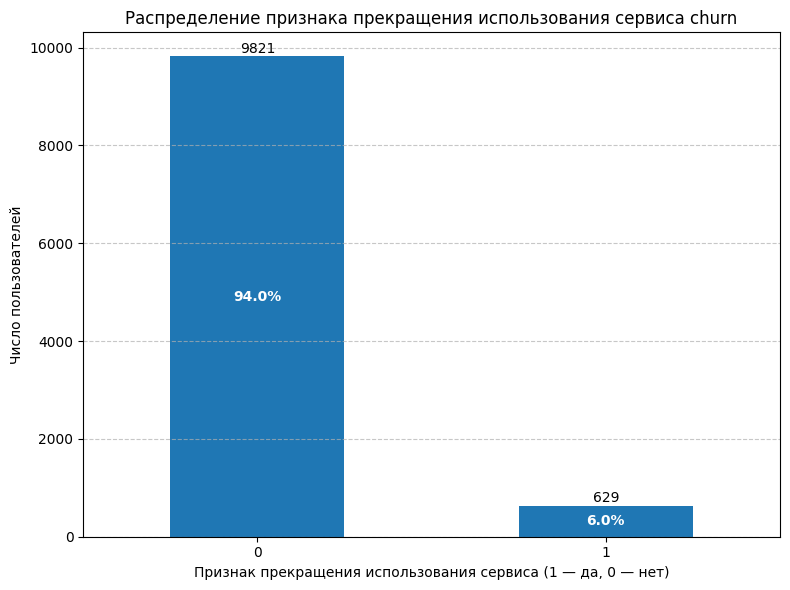

In [16]:
plot_bar_chart(
    df_init['churn'],
    xlabel='Признак прекращения использования сервиса (1 — да, 0 — нет)',
    ylabel='Число пользователей',
    title='Распределение признака прекращения использования сервиса churn',
    figsize=(8, 6)
)


### Комментарий

Целевая переменная `churn` представляет собой флаг признака оттока клиентов: значение 1 - клиент прекратил пользоваться сервисом, 0 - клиент остался в сервисе.  
Явно заметен дисбаланс значений переменной. **6%** пользователей прекратили пользоватьс ясервисом за последние 4 недели. **94%** не имеют такого признака.
___


### 2.3 Описание признаков. Определим, все ли из них важны. Какие из них можно удалить (если такие есть).

In [17]:
df_init.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float32
 2   order_frequency_month     9850 non-null   float32
 3   order_frequency_week      10062 non-null  float32
 4   avg_order_value           9867 non-null   float32
 5   median_order_value        9619 non-null   float32
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float32
 8   discount_usage_rate       10053 non-null  float32
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float32
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

In [18]:
df_processed = df_init.drop(columns=['user_id', 'seasons'])
df_processed.head()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,0.0,12.942519,NaN,316.833862,260.645081,3089.991009,NaN,0.337031,blend,light,almond,NaN,vietnam,large,pro,30.468321,1.0,5.176792,3.302238,NaN,6.0,android,0.0,geo_75,1
1,2.0,1.569146,0.214494,780.135132,540.597839,998.380941,107.369408,0.547659,arabica,light,whole,1.0,guatemala,medium,none,NaN,1.0,4.392991,NaN,0.0,16.0,ios,0.0,geo_95,0
2,11.0,2.996666,0.771864,682.636230,471.494568,1328.140204,392.600006,0.120258,arabica,medium,oat,1.0,guatemala,small,premium,17.895638,1.0,4.977713,4.379219,0.0,11.0,web,1.0,geo_25,0
3,0.0,4.299255,1.210480,2115.487305,708.529785,2999.628366,1084.352051,NaN,robusta,medium,skim,0.0,brazil,medium,none,11.405533,1.0,3.712526,3.043617,0.0,3.0,android,0.0,geo_2,0
4,3.0,7.249865,1.761027,3519.602051,1199.372925,8377.729478,2551.775146,0.074990,robusta,dark,almond,1.0,colombia,medium,none,15.948238,0.0,4.528271,5.642993,1.0,14.0,ios,0.0,geo_19,1


In [19]:
df_processed.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     9505 non-null   float32
 1   order_frequency_month     9850 non-null   float32
 2   order_frequency_week      10062 non-null  float32
 3   avg_order_value           9867 non-null   float32
 4   median_order_value        9619 non-null   float32
 5   total_spent_last_month    10156 non-null  float64
 6   total_spent_last_week     9506 non-null   float32
 7   discount_usage_rate       10053 non-null  float32
 8   last_coffee_type          10192 non-null  str    
 9   preferred_roast           10334 non-null  str    
 10  milk_preference           9782 non-null   str    
 11  seasonal_menu_tried       9461 non-null   float32
 12  coffee_bean_origin        9768 non-null   str    
 13  last_drink_size           9946 non-null   str    
 14  subscription_stat

In [20]:
# обновим после удаления части признаков группы cat_features и создадим binary_features и num_features
cat_features = df_processed.select_dtypes(include=['str']).columns.tolist()
binary_features = [
    'seasonal_menu_tried',
    'notifications_enabled',
    'coffee_preference_change'
]
num_features = [
    'days_since_last_order',
    'order_frequency_month',
    'order_frequency_week',
    'avg_order_value',
    'median_order_value',
    'total_spent_last_month',
    'total_spent_last_week',
    'discount_usage_rate',
    'app_opens_per_week',
    'review_rating_last_10',
    'review_rating_last_1',
    'app_crashes_last_month',
    'days_since_last_promo'
]

### Комментарий

В датасете есть 26 признаков и целевая переменная `churn`.

Информация о пользователях (14 признаков): идентификатор пользователя, предпочитаемый тип обжарки, предпочитаемый тип молока, отметка пробовал ли пользователь сезонное меню, тип подписки пользователя, тип устройства пользователя, сколько раз за неделю пользователь открывал приложение, включены ли уведомления, сколько раз приложение зависало, информация об оценках пользователя, как давно использовалась акция или промокод, менялись ли предпочтения пользователя, регион пользователя.

Информация о заказах пользователей и характеристики этих заказов.  
Числовые характеристики заказов (8 признаков) : число и суммы заказов за неделю и за месяц, средняя и медианная сумма чека, количество дней с последнего заказа, доля заказов со скидкой, размер последнего заказа.  
Категориальные характеристики заказов (3 признака): последний купленный сорт кофе, последний купленный размер кофе, страна происхождения зерна.

Прочая информация: текущее время года (1 признак).

Важными для последующего анализа и построения модели являются числовые и категориальные характеристики заказов, также важны характеристики пользователей, что они предпочитают, какими устройствами пользуются, как стабильно работает приложение и другие.

Почти все атрибуты потенциально могут оказывать влияние на целевую переменную и их необходимо включить в дальнейший анализ.

К признакам, которые не несут в себе полезной информации можно отнести идентификатор пользователя `user_id`. Не ясен статус атрибута текущий сезон `seasons`: данные агрегированы за последние 4 недели, что имелось ввиду под "текущим сезоном" понять затруднительно. Удаляем.

Итого у нас остается 24 признака.
___




### 2.4 Обработка пропущенные значения. Влияние пропусков на данные. Стратегия заполнения пропусков.

In [21]:
def show_missing_stats(df):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': df.isnull().sum(),
        'Доля пропусков': df.isnull().mean()
    }).sort_values(by='Кол-во пропусков', ascending=False)
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))

show_missing_stats(df_processed)

,Кол-во пропусков,Доля пропусков
seasonal_menu_tried,989,0.0946
days_since_last_order,945,0.0904
total_spent_last_week,944,0.0903
subscription_status,938,0.0898
app_opens_per_week,896,0.0857
review_rating_last_1,857,0.0820
median_order_value,831,0.0795
days_since_last_promo,731,0.0700
app_crashes_last_month,721,0.0690
review_rating_last_10,693,0.0663


In [22]:
# Количество атрибутов с пропусками
np.sum(df_processed.isna().sum() > 0)

np.int64(24)

In [23]:
df_processed.sample(20)

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
3836,2.0,3.110860,0.670624,2211.288574,692.064941,1807.774940,335.567261,0.363236,arabica,dark,none,1.0,kenya,medium,basic,3.655202,0.0,4.928036,5.469649,NaN,15.0,android,0.0,geo_2,0
5309,1.0,3.656332,0.725485,340.337189,230.599487,690.645922,154.399750,0.051853,blend,light,oat,0.0,guatemala,medium,basic,8.436757,1.0,5.993368,5.960244,0.0,18.0,ios,0.0,geo_3,0
1146,2.0,0.727308,0.196094,2535.026123,998.632874,816.979310,NaN,0.328728,blend,dark,NaN,1.0,brazil,large,none,NaN,1.0,3.560281,6.113156,1.0,NaN,ios,0.0,geo_3,0
8492,4.0,2.553534,0.609021,980.832581,422.925232,989.568893,308.014343,0.224695,arabica,medium,NaN,1.0,colombia,large,none,7.180116,1.0,3.790309,6.905890,4.0,3.0,web,1.0,geo_30,1
6029,2.0,2.100204,0.567793,558.376892,NaN,1097.439775,NaN,0.123186,robusta,dark,oat,1.0,NaN,NaN,none,NaN,1.0,4.356701,4.012525,0.0,29.0,NaN,1.0,geo_59,0
9396,7.0,13.052323,3.004518,NaN,255.307724,2857.040869,658.934021,0.141069,robusta,light,soy,1.0,NaN,large,basic,15.879971,1.0,4.169512,5.450482,0.0,11.0,ios,0.0,geo_92,0
1744,2.0,2.819495,0.612048,1132.035767,418.420807,1149.131810,NaN,0.127232,robusta,light,none,1.0,kenya,large,none,6.227366,1.0,NaN,1.599233,2.0,62.0,ios,0.0,geo_19,0
3302,23.0,7.989463,1.777450,1249.244141,362.419495,2869.968767,712.427856,0.423983,arabica,light,oat,1.0,kenya,large,none,8.831004,1.0,4.717101,3.859011,1.0,29.0,android,0.0,geo_26,0
2947,1.0,9.646861,2.185412,831.716492,390.825928,3801.496647,685.479675,0.153196,arabica,light,NaN,0.0,kenya,medium,premium,23.276617,1.0,2.346835,7.101951,1.0,10.0,ios,0.0,geo_96,0
336,2.0,5.889068,1.291496,1155.629028,361.242554,1711.019016,437.031738,0.214830,arabica,light,almond,1.0,ethiopia,medium,NaN,7.982195,1.0,NaN,NaN,1.0,10.0,web,0.0,geo_62,0


In [24]:
# Проверяем уникальные значения в столбцах
for column in cat_features:
    print(f'Уникальные значения в столбце {column}:')
    print(df_processed[column].sort_values().unique())
    print('Число уникальных значений:', df_processed[column].sort_values().nunique())
    print()

Уникальные значения в столбце last_coffee_type:
<StringArray>
['arabica', 'blend', 'robusta', nan]
Length: 4, dtype: str
Число уникальных значений: 3

Уникальные значения в столбце preferred_roast:
<StringArray>
['dark', 'light', 'medium', nan]
Length: 4, dtype: str
Число уникальных значений: 3

Уникальные значения в столбце milk_preference:
<StringArray>
['almond', 'none', 'oat', 'skim', 'soy', 'whole', nan]
Length: 7, dtype: str
Число уникальных значений: 6

Уникальные значения в столбце coffee_bean_origin:
<StringArray>
['brazil', 'colombia', 'ethiopia', 'guatemala', 'kenya', 'vietnam', nan]
Length: 7, dtype: str
Число уникальных значений: 6

Уникальные значения в столбце last_drink_size:
<StringArray>
['large', 'medium', 'small', nan]
Length: 4, dtype: str
Число уникальных значений: 3

Уникальные значения в столбце subscription_status:
<StringArray>
['basic', 'none', 'premium', 'pro', nan]
Length: 5, dtype: str
Число уникальных значений: 4

Уникальные значения в столбце phone_type:

In [25]:
df_processed['subscription_status'] = df_processed['subscription_status'].fillna('none')
df_processed['milk_preference'] = df_processed['milk_preference'].fillna('none')

In [26]:
show_missing_stats(df_processed)

,Кол-во пропусков,Доля пропусков
seasonal_menu_tried,989,0.0946
days_since_last_order,945,0.0904
total_spent_last_week,944,0.0903
app_opens_per_week,896,0.0857
review_rating_last_1,857,0.0820
median_order_value,831,0.0795
days_since_last_promo,731,0.0700
app_crashes_last_month,721,0.0690
review_rating_last_10,693,0.0663
coffee_bean_origin,682,0.0653


In [27]:
# Количество атрибутов с пропусками
np.sum(df_processed.isna().sum() > 0)

np.int64(22)

In [28]:
df_processed[df_processed['order_frequency_week'].isna()].head()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,0.0,12.942519,NaN,316.833862,260.645081,3089.991009,NaN,0.337031,blend,light,almond,NaN,vietnam,large,pro,30.468321,1.0,5.176792,3.302238,NaN,6.0,android,0.0,geo_75,1
8,9.0,3.303446,NaN,1886.543945,964.629211,3312.557597,748.655212,0.676576,blend,medium,skim,1.0,guatemala,medium,none,7.129673,1.0,4.405572,NaN,0.0,5.0,android,0.0,geo_45,0
21,5.0,4.289868,NaN,2678.323486,1459.123901,6913.253220,NaN,0.168081,robusta,light,none,1.0,guatemala,large,premium,9.999694,1.0,2.502726,3.759893,1.0,46.0,ios,NaN,geo_94,0
54,11.0,2.724589,NaN,1870.721191,756.890747,1931.968478,444.822388,0.515463,arabica,dark,whole,0.0,vietnam,small,none,NaN,1.0,4.049906,4.635729,1.0,12.0,ios,0.0,geo_97,0
196,0.0,2.991425,NaN,877.869812,349.251160,1024.328734,254.916000,0.498768,arabica,medium,oat,1.0,ethiopia,large,basic,8.602476,0.0,4.187550,3.713239,0.0,4.0,ios,0.0,geo_1,0


In [29]:
df_processed[df_processed['order_frequency_month'].isna()].head()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
19,4.0,NaN,1.013600,258.936157,195.351089,610.308141,207.883087,0.443392,robusta,dark,oat,1.0,colombia,medium,basic,9.730930,1.0,3.692612,3.784187,0.0,33.0,ios,0.0,geo_17,0
36,7.0,NaN,0.694691,1012.886169,486.800598,1418.373591,407.854736,0.186249,arabica,dark,none,1.0,ethiopia,medium,none,2.773921,1.0,3.566735,3.549654,0.0,21.0,android,0.0,geo_1,0
46,7.0,NaN,0.549208,1583.349731,465.959991,1312.432324,179.851929,0.260499,robusta,dark,whole,0.0,vietnam,medium,none,9.491598,1.0,4.857894,4.647859,2.0,23.0,web,1.0,geo_43,0
74,0.0,NaN,2.502107,304.132996,160.229935,1309.437920,387.911102,0.520304,blend,light,none,1.0,vietnam,medium,premium,15.321233,1.0,NaN,3.324303,0.0,5.0,ios,0.0,geo_2,0
79,7.0,NaN,1.205580,46.113434,18.374914,120.562163,18.190657,0.666557,arabica,dark,whole,0.0,brazil,large,premium,3.173590,0.0,4.656898,3.508681,1.0,2.0,ios,0.0,geo_2,0


In [30]:
df_processed[df_processed['total_spent_last_week'].isna()].head()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,0.0,12.942519,NaN,316.833862,260.645081,3089.991009,NaN,0.337031,blend,light,almond,NaN,vietnam,large,pro,30.468321,1.0,5.176792,3.302238,NaN,6.0,android,0.0,geo_75,1
17,3.0,3.503378,0.936460,1001.051575,405.030457,1584.914584,NaN,0.435147,arabica,dark,oat,0.0,NaN,medium,premium,17.655357,1.0,5.683203,5.187074,0.0,NaN,ios,0.0,geo_3,0
21,5.0,4.289868,NaN,2678.323486,1459.123901,6913.253220,NaN,0.168081,robusta,light,none,1.0,guatemala,large,premium,9.999694,1.0,2.502726,3.759893,1.0,46.0,ios,NaN,geo_94,0
43,2.0,1.379313,0.289451,1235.152954,NaN,947.938062,NaN,0.438557,robusta,medium,whole,0.0,guatemala,NaN,basic,7.711953,1.0,3.006368,NaN,1.0,33.0,android,0.0,geo_100,0
57,2.0,5.445011,1.373850,765.754333,299.811218,1885.775446,NaN,0.465748,robusta,dark,whole,0.0,ethiopia,medium,premium,17.341873,1.0,4.964828,3.794571,0.0,32.0,ios,0.0,NaN,0


In [31]:
df_processed[df_processed['total_spent_last_month'].isna()].head()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
7,3.0,4.640247,1.029297,27.368788,9.812365,NaN,10.523664,0.173646,robusta,light,almond,1.0,brazil,small,basic,14.785010,1.0,4.793547,4.321319,3.0,12.0,android,0.0,geo_3,1
18,0.0,5.236275,1.132846,2288.324707,801.929688,NaN,1000.598877,0.296605,arabica,light,skim,1.0,colombia,medium,none,6.201520,0.0,4.415193,3.125482,0.0,15.0,android,0.0,geo_2,0
39,11.0,2.997699,0.635281,1729.047852,884.359314,NaN,609.195129,0.180354,arabica,medium,none,1.0,kenya,medium,premium,7.941270,0.0,3.569873,2.650999,2.0,6.0,ios,1.0,NaN,0
77,6.0,2.318445,0.392752,1595.760376,671.527344,NaN,224.996048,0.115047,arabica,dark,oat,1.0,brazil,small,none,3.136085,1.0,4.390393,3.071448,0.0,3.0,ios,0.0,geo_1,0
80,4.0,7.813909,1.896021,748.838928,306.484528,NaN,581.097290,0.068763,arabica,light,oat,0.0,kenya,small,none,11.899315,0.0,NaN,5.466691,0.0,22.0,android,0.0,geo_3,0


In [32]:
def fill_missing_values(row):
    """
    Заполняет пропуски в парах полей week-month:
    - Если есть значение month, а week пуст — заполняет week = month / 4
    - Если есть значение week, а month пуст — заполняет month = week * 4
    - Если оба поля пусты — оставляет как есть

    Параметры:
    -----------
    row : pd.Series
        Строка датафрейма

    Возвращает:
    -----------
    pd.Series
        Обновлённая строка с заполненными пропусками (если возможно)
    """
    # Создаём копию строки, чтобы не изменять оригинальный датафрейм
    new_row = row.copy()

    # Пара: order_frequency_month и order_frequency_week
    freq_month = row['order_frequency_month']
    freq_week = row['order_frequency_week']

    if pd.isna(freq_week) and not pd.isna(freq_month):
        # Если week пуст, а month есть — заполняем week = month / 4
        new_row['order_frequency_week'] = freq_month / 4

    elif pd.isna(freq_month) and not pd.isna(freq_week):
        # Если month пуст, а week есть — заполняем month = week * 4
        new_row['order_frequency_month'] = freq_week * 4

    # Пара: total_spent_last_month и total_spent_last_week
    spent_month = row['total_spent_last_month']
    spent_week = row['total_spent_last_week']

    if pd.isna(spent_week) and not pd.isna(spent_month):
        # Если week пуст, а month есть — заполняем week = month / 4
        new_row['total_spent_last_week'] = spent_month / 4

    elif pd.isna(spent_month) and not pd.isna(spent_week):
        # Если month пуст, а week есть — заполняем month = week * 4
        new_row['total_spent_last_month'] = spent_week * 4

    return new_row


In [33]:
show_missing_stats(df_processed[['order_frequency_week', 'order_frequency_month', 'total_spent_last_week', 'total_spent_last_month']])

,Кол-во пропусков,Доля пропусков
total_spent_last_week,944,0.0903
order_frequency_month,600,0.0574
order_frequency_week,388,0.0371
total_spent_last_month,294,0.0281


In [34]:
# Применение функции к датафрейму
df_processed = df_processed.apply(fill_missing_values, axis=1)

In [35]:
# Проверим заполнение в строке с индексом 0, где были пустые значения для order_frequency_week и total_spent_last_week
df_processed.iloc[:1]

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,0.0,12.942519,3.23563,316.833862,260.645081,3089.991009,772.497752,0.337031,blend,light,almond,NaN,vietnam,large,pro,30.468321,1.0,5.176792,3.302238,NaN,6.0,android,0.0,geo_75,1


In [36]:
# Проверим заполнение в строке с индексами 18 и 19, где были пустые значения для order_frequency_month и total_spent_last_month
df_processed.iloc[18:20]

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
18,0.0,5.236275,1.132846,2288.324707,801.929688,4002.395508,1000.598877,0.296605,arabica,light,skim,1.0,colombia,medium,none,6.20152,0.0,4.415193,3.125482,0.0,15.0,android,0.0,geo_2,0
19,4.0,4.054400,1.013600,258.936157,195.351089,610.308141,207.883087,0.443392,robusta,dark,oat,1.0,colombia,medium,basic,9.73093,1.0,3.692612,3.784187,0.0,33.0,ios,0.0,geo_17,0


In [37]:
show_missing_stats(df_processed[['order_frequency_week', 'order_frequency_month', 'total_spent_last_week', 'total_spent_last_month']])

,Кол-во пропусков,Доля пропусков
total_spent_last_month,30,0.0029
total_spent_last_week,30,0.0029
order_frequency_month,22,0.0021
order_frequency_week,22,0.0021


### Комментарий

Все 24 признака содержат пропуски. Больше всего пропусков в `seasonal_menu_tried` (989 пустых значений, 9.5%) `days_since_last_order` (945 пустых значений, 9% пропусков), `total_spent_last_week` (944 значения, 9%). Меньше всего пропусков (менее 3%) в атрибутах `total_spent_last_month`, `last_coffee_type`, `preferred_roast` и `geo_location`.

Обработать большинство пропусков без риска утечки данных невозможно.

Числовые атрибуты `days_since_last_order`, `order_frequency_month`, `order_frequency_week`, `avg_order_value`, `median_order_value`, `total_spent_last_month`, `total_spent_last_week`, `discount_usage_rate`, `app_opens_per_week`, `review_rating_last_10`, `review_rating_last_1`, `app_crashes_last_month`, `days_since_last_promo` - пропуски требуют замены мерами центральной тенденции (средним или медианой).

Категориальные атрибуты `last_coffee_type`, `preferred_roast`, `coffee_bean_origin`, `last_drink_size`, `phone_type`, `geo_location` - необходимо заполнить наиболее часто встречающимися значениями.

Бинарные атрибуты `seasonal_menu_tried`, `notifications_enabled`, `coffee_preference_change` - если предположить, что пропуски типа **Missing Completely at Random, MCAR**, то можно заполнить в них имеющейся пропорции значений 1 и 0 для сохранения общей картины

Атрибут, который можно заполнить без риска утечки данных - это `subscription_status` и `milk_preference`. Пустые значения заменяем на имеющуюся категорию 'none'. Пропуски заполняются полностью.  

Также без риска утечки даннных можно восстановить те значения полей `order_frequency_month`, `order_frequency_week`, `total_spent_last_month`, `total_spent_last_week`, где есть заполненное парное значение week-month. Скорее всегоэто тип **Missing Not at Random (MNAR)**. А значит для week можно сделать заполнение деление на 4 значения month. Соответственно для month - умножением на 4 значения, имеющего в week. 
Выбор множителя 4 обусловлен тем, что данные агрегированы за последние 4 недели. В результате восстановления данных число пропусков в упомянутых 4-х полях **снизилось с 2-9% до 0.2%**.

___

### 2.5 Анализ категориальных признаков. Кодирование. Генерация новых признаков. Удаление ненужных признаков.

In [38]:
df_processed[cat_features].describe()

,last_coffee_type,preferred_roast,milk_preference,coffee_bean_origin,last_drink_size,subscription_status,phone_type,geo_location
count,10192,10334,10450,9768,9946,10450,10114,10340
unique,3,3,6,6,3,4,3,100
top,arabica,medium,whole,ethiopia,medium,none,android,geo_2
freq,6134,3458,2876,1690,4925,4741,4611,1629


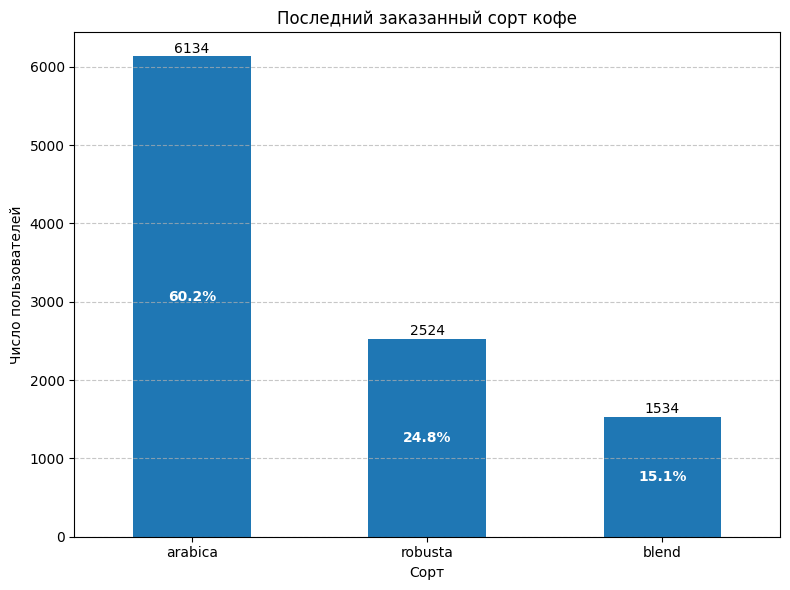

In [39]:
plot_bar_chart(
    df_processed['last_coffee_type'],
    xlabel='Сорт',
    ylabel='Число пользователей',
    title='Последний заказанный сорт кофе',
    figsize=(8, 6)
)

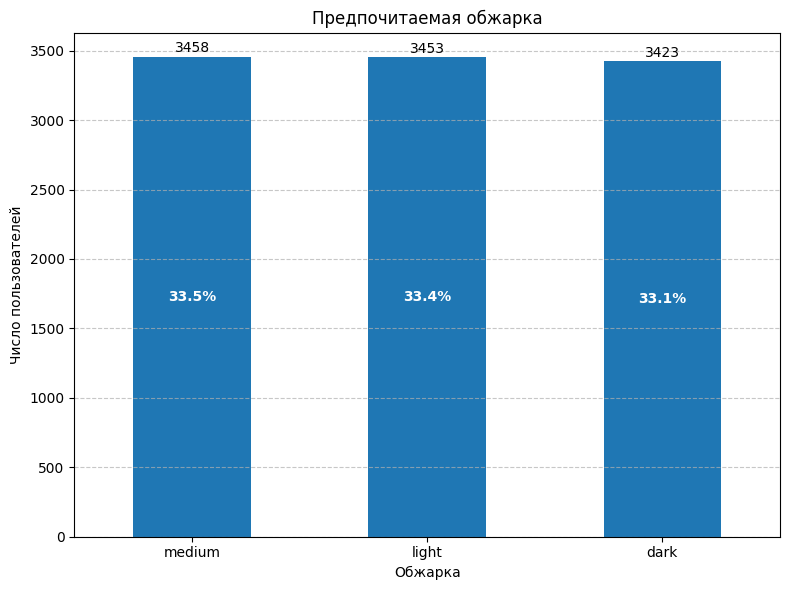

In [40]:
plot_bar_chart(
    df_processed['preferred_roast'],
    xlabel='Обжарка',
    ylabel='Число пользователей',
    title='Предпочитаемая обжарка',
    figsize=(8, 6)

)

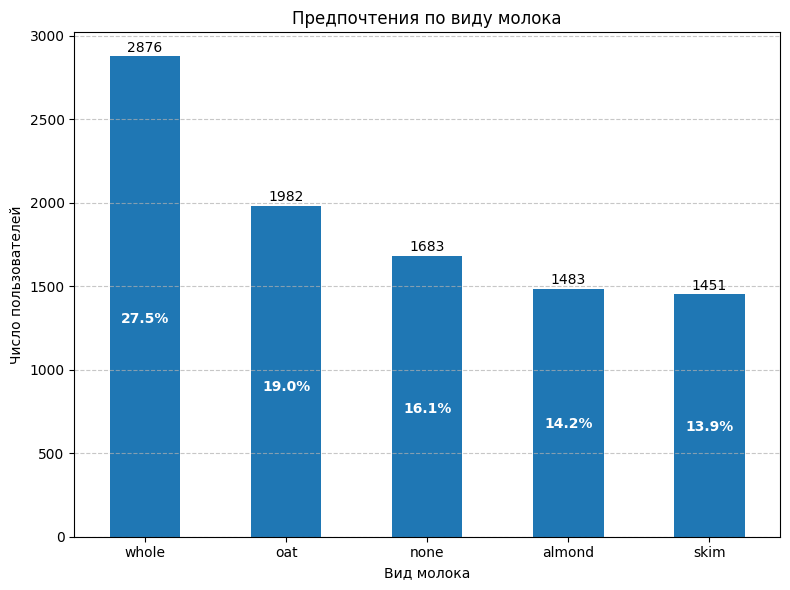

In [41]:
plot_bar_chart(
    df_processed['milk_preference'],
    xlabel='Вид молока',
    ylabel='Число пользователей',
    title='Предпочтения по виду молока',
    figsize=(8, 6)
)

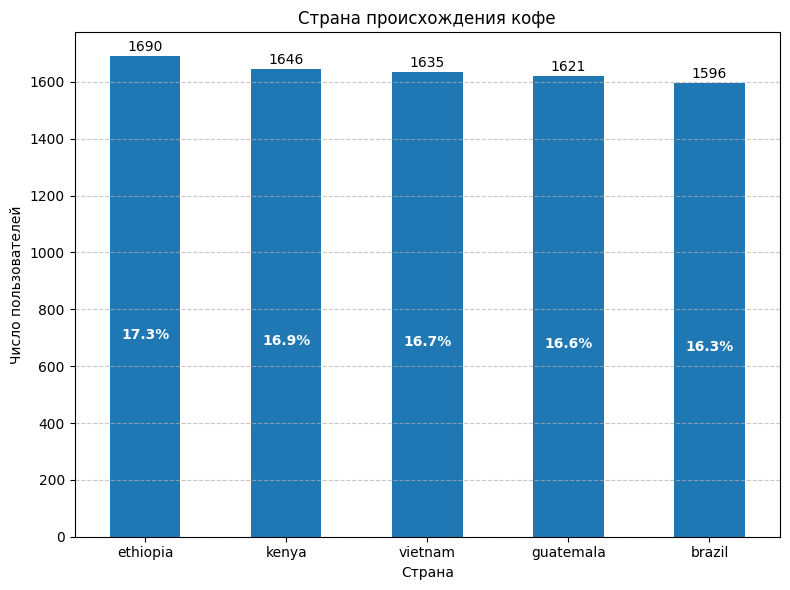

In [42]:
plot_bar_chart(
    df_processed['coffee_bean_origin'],
    xlabel='Страна',
    ylabel='Число пользователей',
    title='Страна происхождения кофе',
    figsize=(8, 6)
)

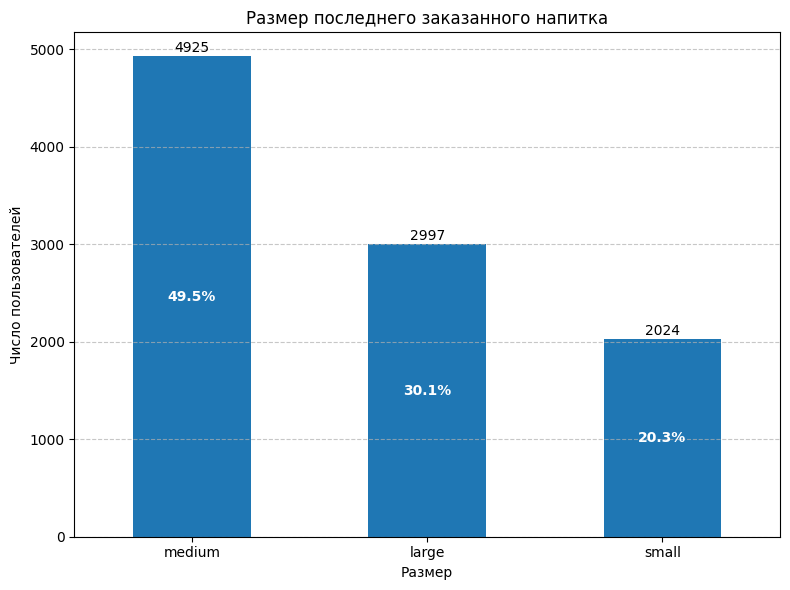

In [43]:
plot_bar_chart(
    df_processed['last_drink_size'],
    xlabel='Размер',
    ylabel='Число пользователей',
    title='Размер последнего заказанного напитка',
    figsize=(8, 6)
)

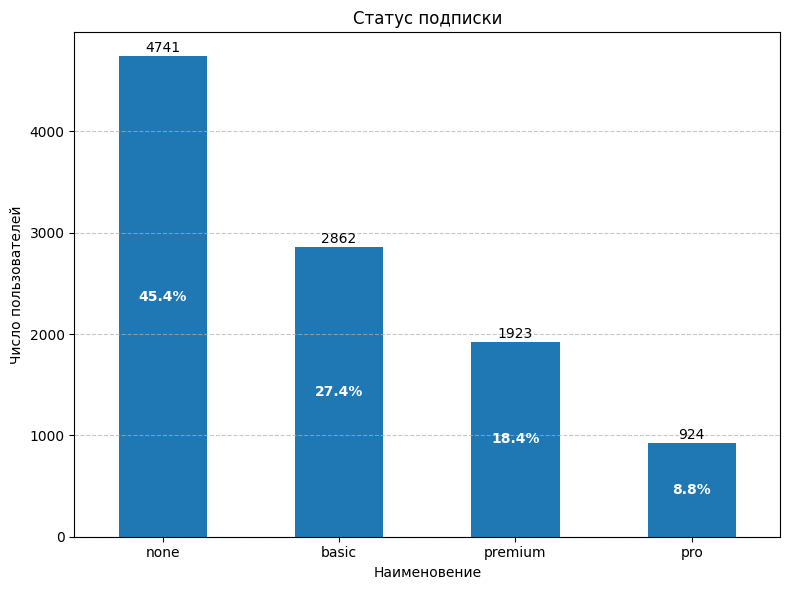

In [44]:
plot_bar_chart(
    df_processed['subscription_status'],
    xlabel='Наименовение',
    ylabel='Число пользователей',
    title='Статус подписки',
    figsize=(8, 6)
)

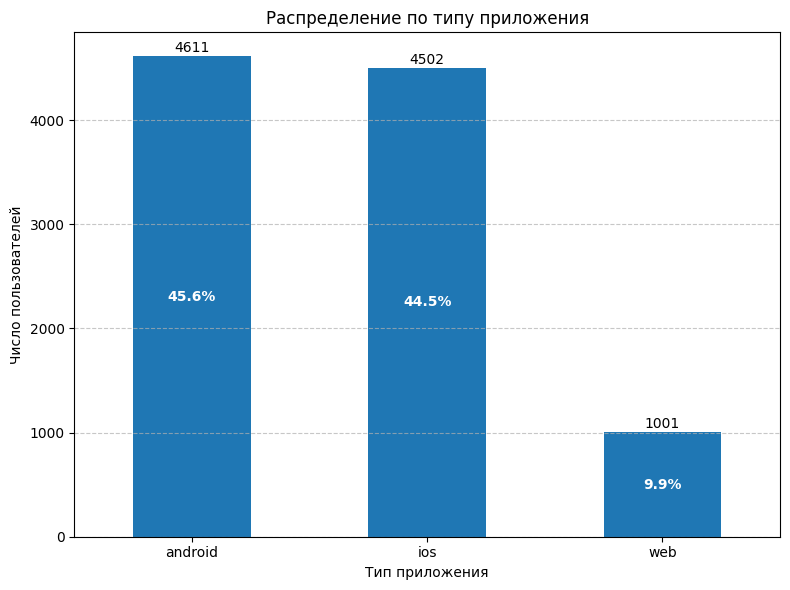

In [45]:
plot_bar_chart(
    df_processed['phone_type'],
    xlabel='Тип приложения',
    ylabel='Число пользователей',
    title='Распределение по типу приложения',
    figsize=(8, 6)
)

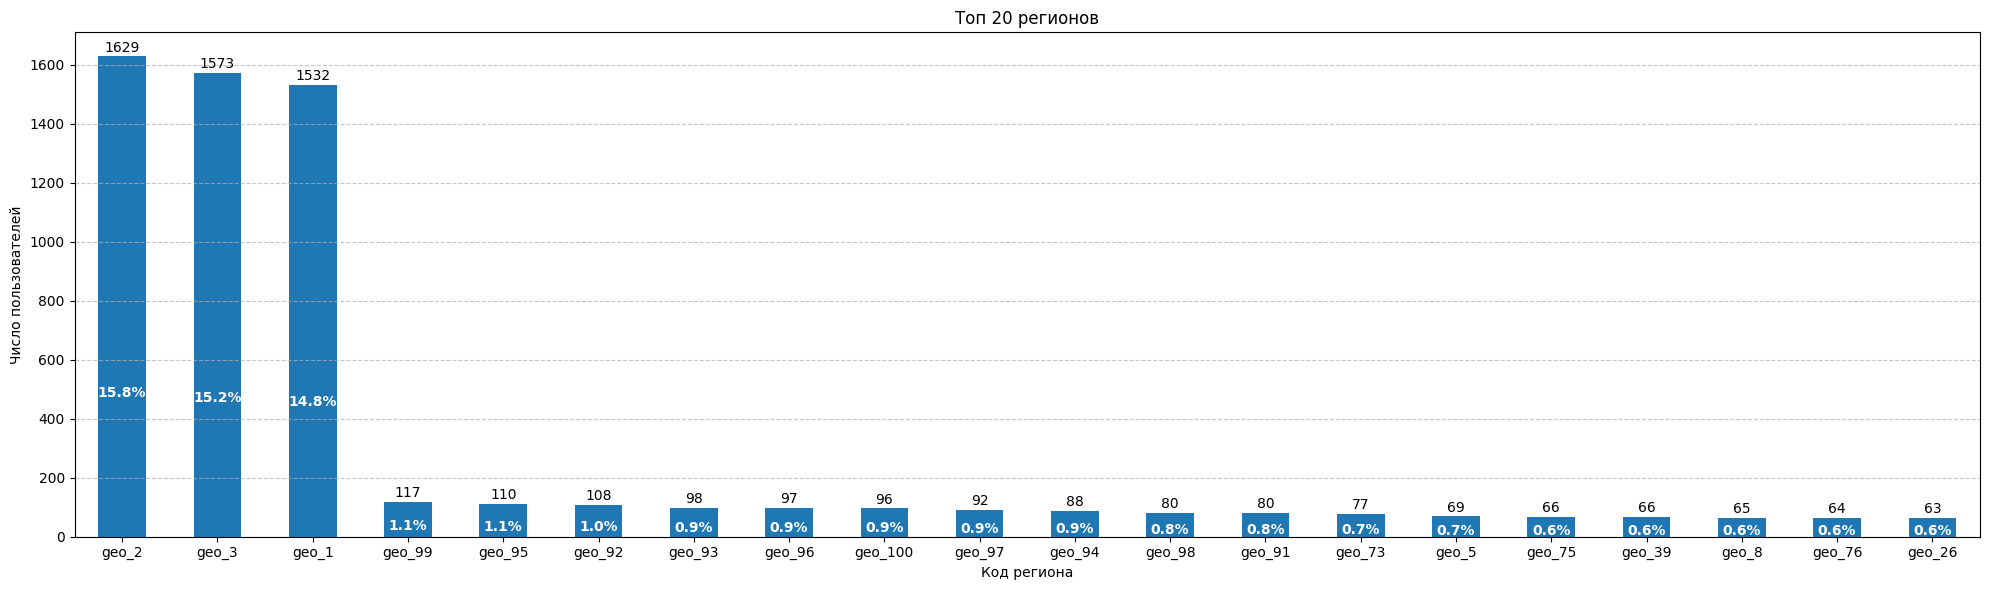

In [46]:
plot_bar_chart(
    df_processed['geo_location'],
    xlabel='Код региона',
    ylabel='Число пользователей',
    title='Топ 20 регионов',
    top_n=20,
    figsize=(20, 6)
)

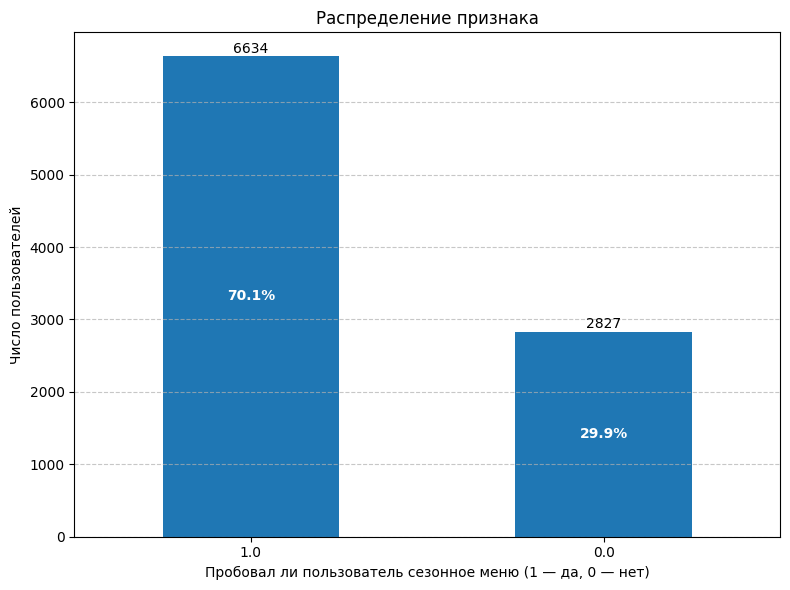

In [47]:
plot_bar_chart(
    df_processed['seasonal_menu_tried'],
    xlabel='Пробовал ли пользователь сезонное меню (1 — да, 0 — нет)',
    ylabel='Число пользователей',
    title='Распределение признака',
    figsize=(8, 6)
)

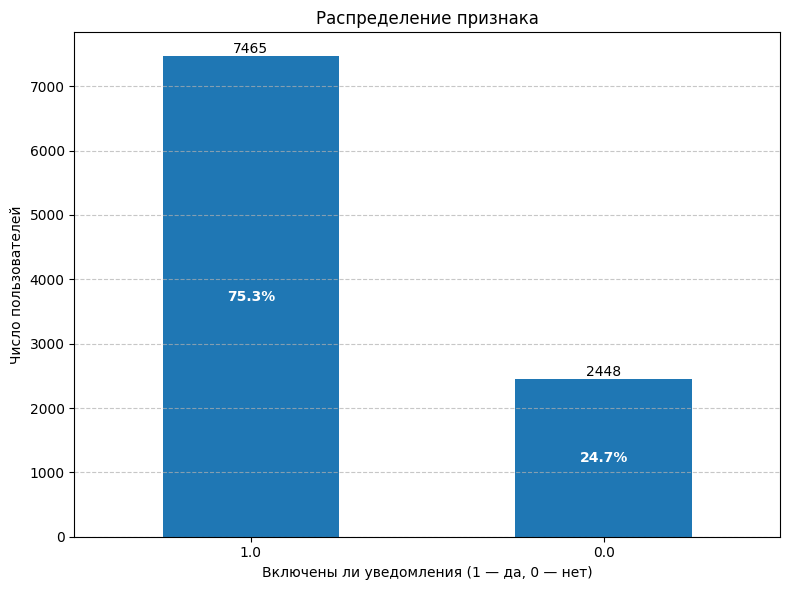

In [48]:
plot_bar_chart(
    df_processed['notifications_enabled'],
    xlabel='Включены ли уведомления (1 — да, 0 — нет)',
    ylabel='Число пользователей',
    title='Распределение признака',
    figsize=(8, 6)
)

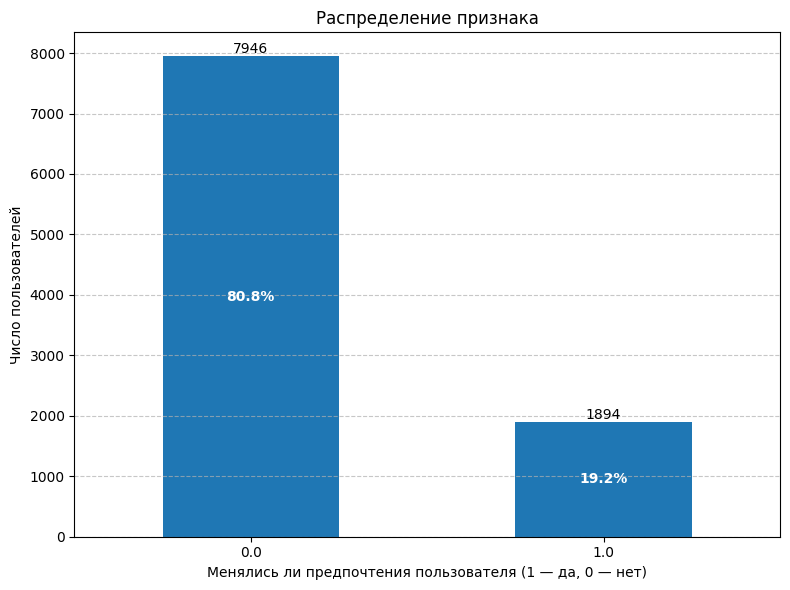

In [49]:
plot_bar_chart(
    df_processed['coffee_preference_change'],
    xlabel='Менялись ли предпочтения пользователя (1 — да, 0 — нет)',
    ylabel='Число пользователей',
    title='Распределение признака',
    figsize=(8, 6)
)

In [50]:
df_processed[binary_features].describe()

,seasonal_menu_tried,notifications_enabled,coffee_preference_change
count,9461.000000,9913.000000,9840.000000
mean,0.701194,0.753052,0.192480
std,0.457759,0.431258,0.394268
min,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000
50%,1.000000,1.000000,0.000000
75%,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000


In [51]:
df_processed = df_processed.drop(columns=['coffee_bean_origin', 'last_coffee_type', 'preferred_roast', 'milk_preference', 'last_drink_size'])

cat_features = df_processed.select_dtypes(include=['str']).columns.tolist()

In [52]:
show_missing_stats(df_processed[cat_features + binary_features])

,Кол-во пропусков,Доля пропусков
seasonal_menu_tried,989,0.0946
coffee_preference_change,610,0.0584
notifications_enabled,537,0.0514
phone_type,336,0.0322
geo_location,110,0.0105


In [53]:
# Проверяем уникальные значения в столбцах
for column in cat_features + binary_features:
    print(f'Уникальные значения в столбце {column}:')
    print(df_processed[column].sort_values().unique())
    print('Число уникальных значений:', df_processed[column].sort_values().nunique())
    print()

Уникальные значения в столбце subscription_status:
<StringArray>
['basic', 'none', 'premium', 'pro']
Length: 4, dtype: str
Число уникальных значений: 4

Уникальные значения в столбце phone_type:
<StringArray>
['android', 'ios', 'web', nan]
Length: 4, dtype: str
Число уникальных значений: 3

Уникальные значения в столбце geo_location:
<StringArray>
[  'geo_1',  'geo_10', 'geo_100',  'geo_11',  'geo_12',  'geo_13',  'geo_14',
  'geo_15',  'geo_16',  'geo_17',
 ...
  'geo_91',  'geo_92',  'geo_93',  'geo_94',  'geo_95',  'geo_96',  'geo_97',
  'geo_98',  'geo_99',       nan]
Length: 101, dtype: str
Число уникальных значений: 100

Уникальные значения в столбце seasonal_menu_tried:
[ 0.  1. nan]
Число уникальных значений: 2

Уникальные значения в столбце notifications_enabled:
[ 0.  1. nan]
Число уникальных значений: 2

Уникальные значения в столбце coffee_preference_change:
[ 0.  1. nan]
Число уникальных значений: 2



### Комментарий

Датасет содержит 8 категориальных признаков (`last_coffee_type`, `preferred_roast`, `milk_preference`, `coffee_bean_origin`, `last_drink_size`, `subscription_status`, `phone_type`, `geo_location`) и 3 бинарных (`seasonal_menu_tried`, `notifications_enabled`, `coffee_preference_change`).

Анализ категориальных признаков выявляет преобладание сорта arabica (6 134 случая, ~60% от выборки), при этом наиболее частым выбором обжарки выступает medium (3 458, ~33%). Среди молока лидирует whole (2 876, ~27%). Средний размер порции (medium, 4 925, ~50%) остаётся самым популярным, а география фиксирует максимальную концентрацию в сегменте geo_2 (1 629, ~16%). Основная часть пользователей не имеет подписки (none, 4 741, ~45%), а платформой взаимодействия преимущественно служит android (4 611, ~45%). Лидером по происхождению зёрен выступает ethiopia (1 690, ~17%). Более 45% пользовалей приходитс яна 3 региона: geo_2 (15.8%), geo_3 (15.2%), geo_1 (14.8%).

Сомнительно, что влияние на целевую переменную могут оказать страна происхождение кофе `coffee_bean_origin`, сорт кофе `last_coffee_type`, тип обжарки `preferred_roast`, предпочтение по типу молока `milk_preference` и размер последнего заказанного напитка `last_drink_size`. Это признаки, которые скорее отражают общее состояние рынка и не несут какой то специфической информации конкретно о нашем сервисе. Эти признаки можно удалить.

Для оставшихся категориальных признаков `subscription_status`, `phone_type` с 3-4 уникальным значениями будем применять технику **One hot encoding**. Признак `geo_location`, который имеет 100 уникальных значений. В этом случае больше подойдет **Target Encoding** с кодированием по среднему значению целевой переменной для заданной категории.

Для бинарных признаков специальная кодировка не требуется, эти признаки оставим как есть (нужно будет заполнить пропуски). Распределение бинарных признаков несбалансировано. Для `seasonal_menu_tried` и `notifications_enabled` большая часть значений приходится на 1 (70 и 75%, соответственно). Признак `coffee_preference_change` имеет почти 81% нулевых значений. Пользователи не склонны менять предпочтения по кофе.

Для генерации новых признаков на основе имеющихся категориальных можно попробовать объединить `subscription_status` + `phone_type`. Потенциально тут могут быть закономерности связанные с типом телефона и состоянием подписки. Преобладает ли среди владельцев iPhone (IoS) подписка premium и какова лояльность этой группы клиентов.

Если новые сконструированный признак покажет свою значимость его можно будет оставить в модели, удалив те, что были использованы для их создания.  

---

### 2.6 Анализ выбросов. Влияние на данные. Выбор способа обработки.

In [54]:
df_processed[num_features].describe()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,app_opens_per_week,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo
count,9505.000000,10428.000000,10428.000000,9867.000000,9619.000000,10420.000000,10420.000000,10053.000000,9554.000000,9757.000000,9593.000000,9729.000000,9719.000000
mean,4.394214,4.011096,0.934640,1063.741206,452.651500,1940.130434,421.280060,0.284446,11.330895,4.206709,4.022460,1.013362,14.554584
std,4.858757,2.813877,0.662213,707.713395,258.657570,2357.760088,466.375042,0.158735,14.528887,0.782212,1.207883,1.010342,15.308869
min,0.000000,-0.607719,-0.169131,-32.075932,-10.353340,-646.407898,-2290.559570,0.002162,0.000000,1.415526,-0.897000,0.000000,0.000000
25%,1.000000,1.939899,0.447252,552.898682,262.908600,628.013177,137.943287,0.159884,6.313628,3.675543,3.214157,0.000000,4.000000
50%,3.000000,3.376917,0.787035,898.643555,406.456818,1292.497153,290.740616,0.264583,9.228383,4.203555,3.990031,1.000000,10.000000
75%,6.000000,5.407691,1.265991,1406.332153,590.418060,2471.332146,553.090332,0.387056,12.726650,4.717292,4.845225,2.000000,20.000000
max,40.000000,27.389318,6.302624,5901.965332,2189.101562,79298.849570,8615.989258,0.887301,224.587875,7.384425,8.558442,7.000000,140.000000


In [55]:
num_features

['days_since_last_order',
 'order_frequency_month',
 'order_frequency_week',
 'avg_order_value',
 'median_order_value',
 'total_spent_last_month',
 'total_spent_last_week',
 'discount_usage_rate',
 'app_opens_per_week',
 'review_rating_last_10',
 'review_rating_last_1',
 'app_crashes_last_month',
 'days_since_last_promo']

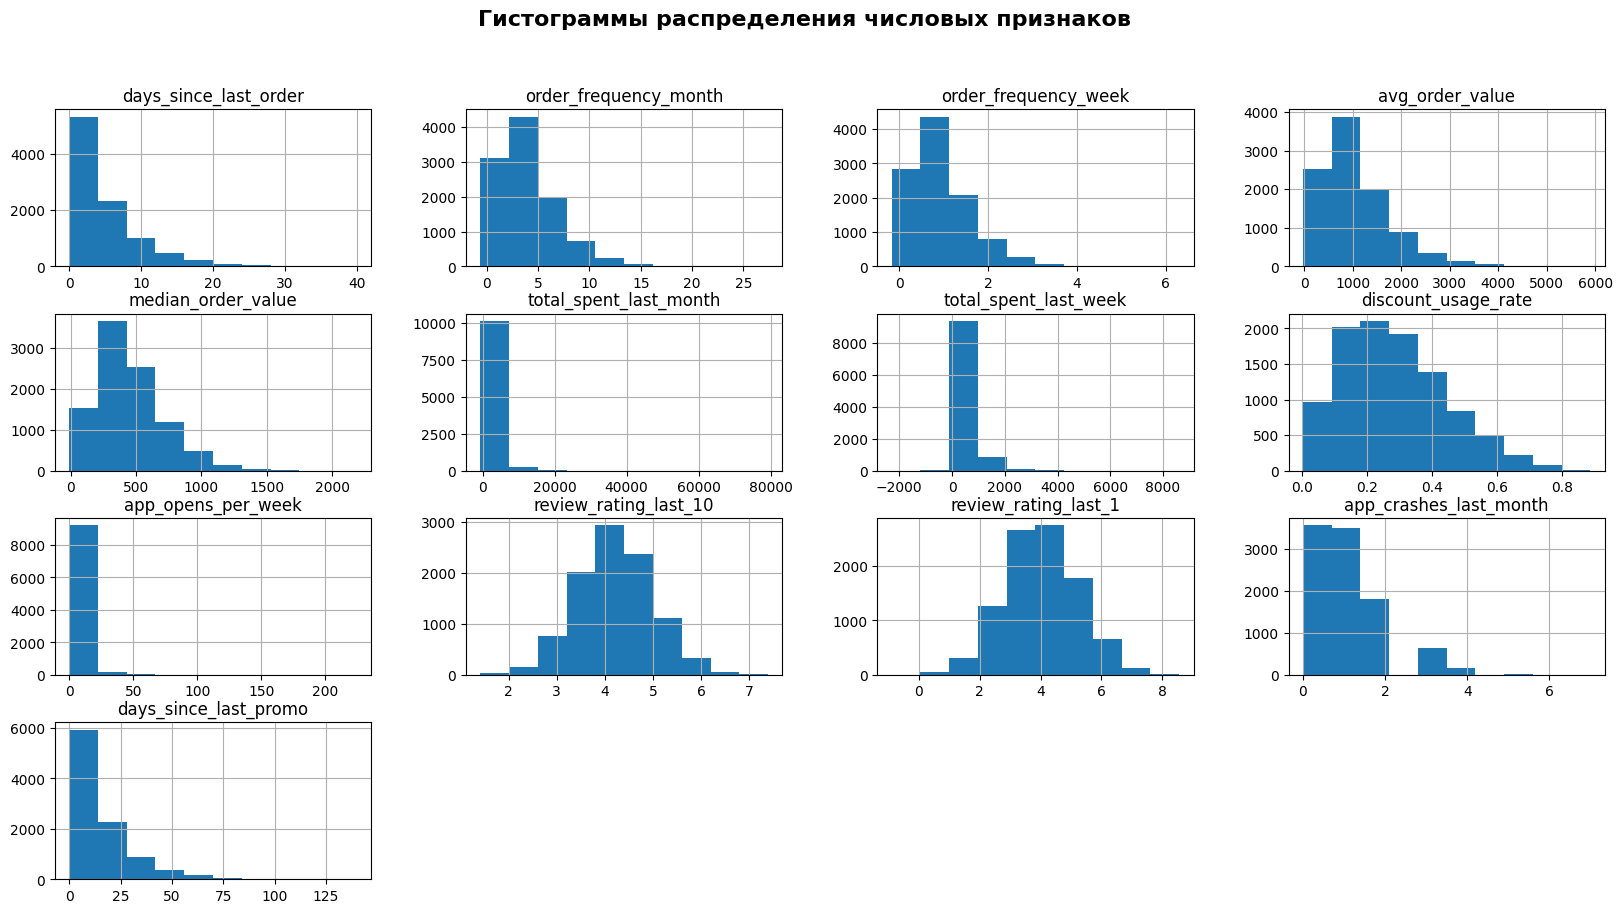

In [56]:
df_processed[num_features].hist(figsize=(20, 10))
plt.suptitle('Гистограммы распределения числовых признаков', fontsize=16, fontweight='bold')
plt.show()

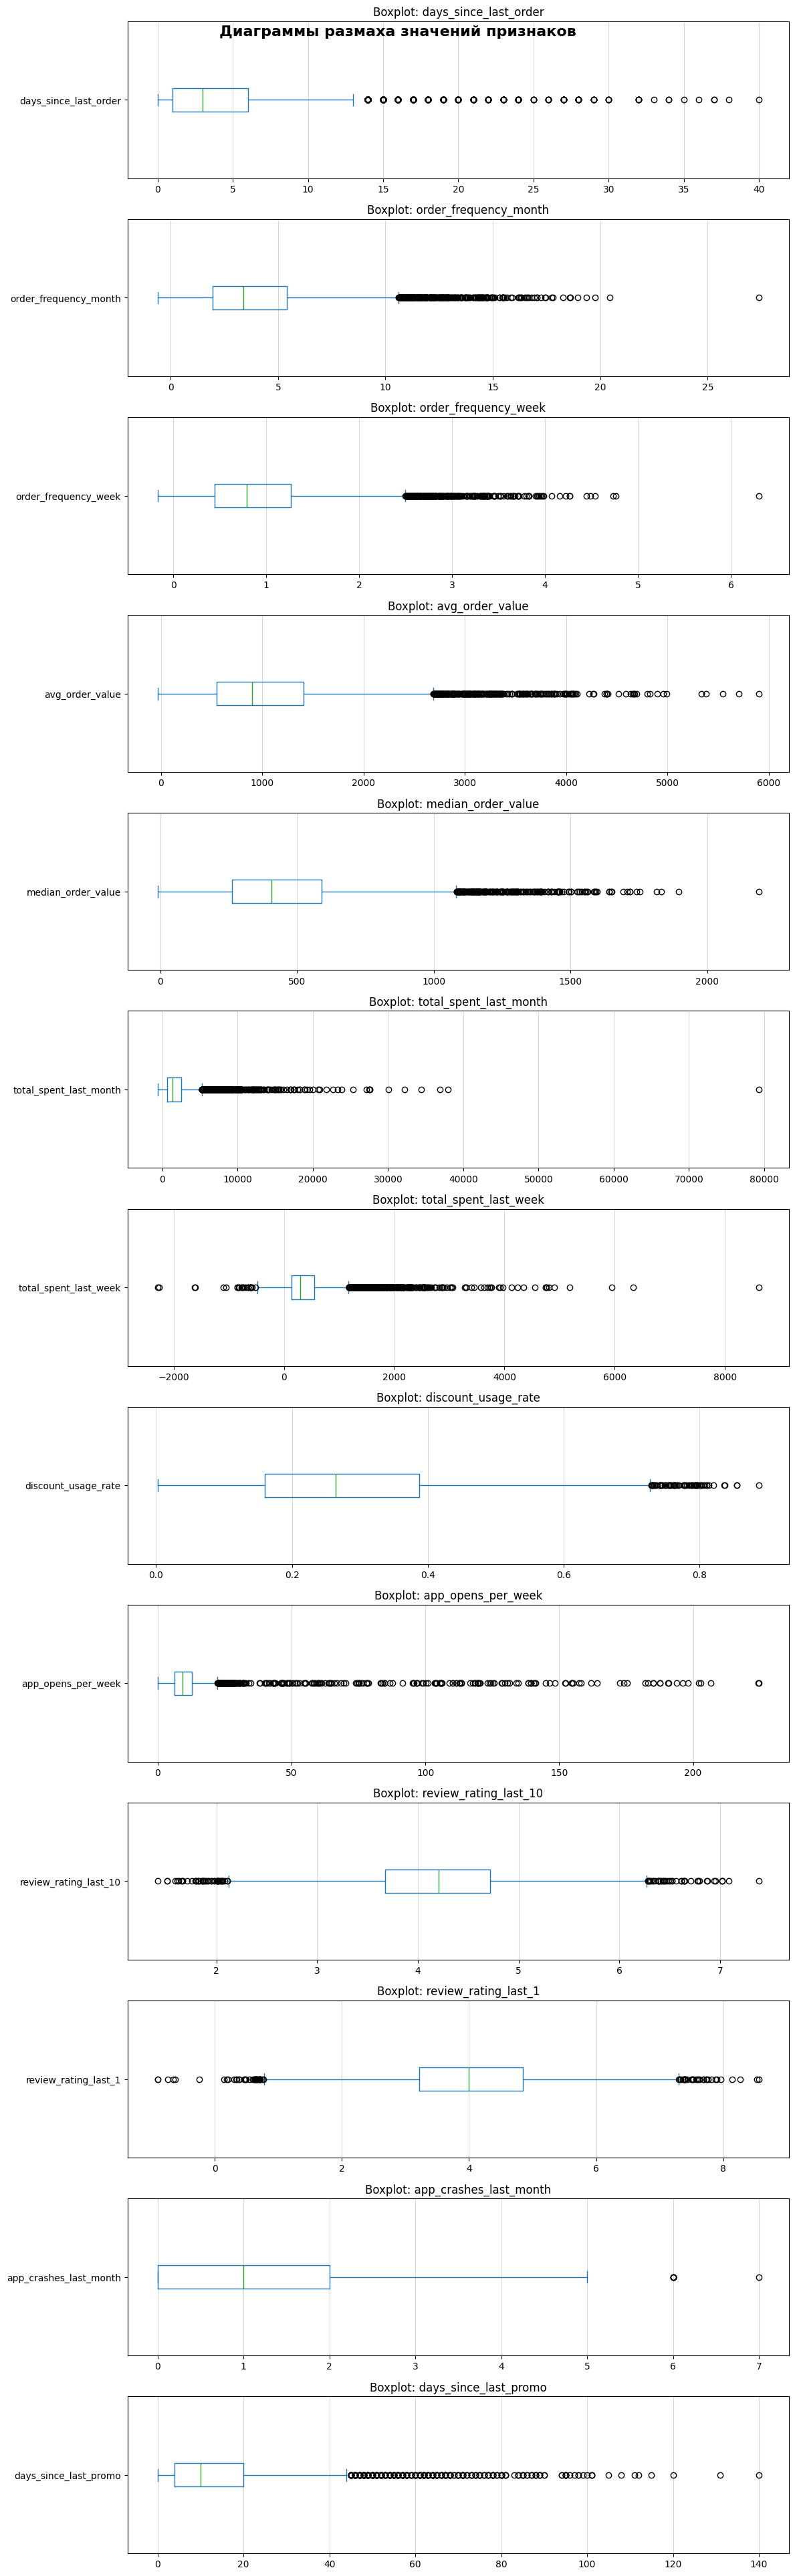

In [57]:
fig, axes = plt.subplots(nrows=len(num_features), ncols=1, figsize=(12, 3 * len(num_features)))

for i, feature in enumerate(num_features):
    df_processed[feature].plot.box(ax=axes[i], vert=False)
    axes[i].set_title(f'Boxplot: {feature}')
    axes[i].tick_params(axis='x', labelrotation=0)
    axes[i].grid(axis='x', alpha=0.5) 

plt.suptitle('Диаграммы размаха значений признаков', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [58]:
df_processed.describe()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,10428.000000,10428.000000,9867.000000,9619.000000,10420.000000,10420.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.011096,0.934640,1063.741206,452.651500,1940.130434,421.280060,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.813877,0.662213,707.713395,258.657570,2357.760088,466.375042,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,-0.607719,-0.169131,-32.075932,-10.353340,-646.407898,-2290.559570,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.939899,0.447252,552.898682,262.908600,628.013177,137.943287,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.376917,0.787035,898.643555,406.456818,1292.497153,290.740616,0.264583,1.000000,9.228383,1.000000,4.203555,3.990031,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.407691,1.265991,1406.332153,590.418060,2471.332146,553.090332,0.387056,1.000000,12.726650,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965332,2189.101562,79298.849570,8615.989258,0.887301,1.000000,224.587875,1.000000,7.384425,8.558442,7.000000,140.000000,1.000000,1.000000


In [59]:
df_processed[df_processed['total_spent_last_week'] < 0].head()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
9,0.0,0.310724,-0.094052,607.847839,NaN,151.508968,-41.895977,NaN,NaN,none,6.706418,1.0,4.362385,2.624536,2.0,14.0,ios,0.0,geo_2,0
188,3.0,5.019632,1.195954,1546.929443,654.213257,3057.644199,-646.719116,0.055872,NaN,premium,18.613766,0.0,5.249486,5.151920,1.0,NaN,android,1.0,geo_36,0
191,2.0,0.199242,-0.169131,3710.492920,1131.554688,257.097416,-237.899445,0.115694,1.0,none,5.022469,0.0,5.132989,3.098811,2.0,17.0,android,1.0,geo_15,0
193,24.0,2.542895,0.567124,1342.726196,522.184875,1202.395592,-344.924286,0.223425,1.0,none,12.251356,NaN,5.147882,3.638431,2.0,6.0,android,1.0,geo_76,0
345,2.0,1.132874,-0.074783,715.372314,207.050400,238.475342,-11.382833,0.365909,1.0,premium,5.045229,1.0,4.073474,2.330635,2.0,NaN,android,0.0,geo_21,0


In [60]:
df_processed[df_processed['total_spent_last_week'] < 0].shape[0]

171

In [61]:
df_processed[df_processed['total_spent_last_month'] < 0].head()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
3011,3.0,2.512251,0.488258,609.797485,465.448029,-646.407898,-161.601974,0.450367,1.0,none,3.050122,1.0,4.537257,NaN,1.0,45.0,ios,0.0,geo_96,0
8176,0.0,3.839381,1.043652,-32.075932,-10.353340,-43.716463,-11.723440,0.500261,1.0,basic,13.652514,1.0,5.113545,5.153962,0.0,20.0,NaN,0.0,geo_1,0
9024,1.0,0.576902,-0.054091,183.976898,101.922356,-27.727970,-6.931993,0.369480,1.0,none,7.791657,1.0,3.030349,5.461210,2.0,17.0,ios,0.0,geo_3,0
9233,6.0,2.220828,0.689320,-24.970131,-7.325263,-14.737615,-3.650004,0.101484,1.0,none,6.756336,1.0,3.720842,2.738778,1.0,1.0,web,0.0,geo_96,0


In [62]:
df_processed[df_processed['total_spent_last_month'] < 0].shape[0]

4

In [63]:
df_processed[df_processed['review_rating_last_1'] < 0]

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
3569,16.0,2.378596,0.517216,2207.281982,975.471741,2086.681417,400.474670,0.219084,NaN,basic,NaN,0.0,4.194786,-0.654883,2.0,24.0,android,1.0,geo_3,0
4626,0.0,1.300067,0.373419,1132.874268,562.879211,689.480395,262.098175,0.223964,1.0,basic,5.851124,0.0,4.191055,-0.733524,2.0,NaN,android,0.0,geo_48,0
8044,2.0,3.410534,0.899947,250.475296,157.230103,627.714176,170.931625,0.508307,NaN,none,4.259049,0.0,4.490215,-0.897000,0.0,29.0,android,0.0,geo_1,0
8125,2.0,1.376997,0.345475,NaN,716.698303,1056.574986,304.503906,0.077841,1.0,pro,17.125406,0.0,4.042738,-0.241400,3.0,21.0,android,0.0,geo_3,0
9150,2.0,3.410534,0.899947,250.475296,157.230103,627.714176,170.931625,0.508307,NaN,none,4.259049,0.0,4.490215,-0.897000,0.0,29.0,android,0.0,geo_1,0
10214,0.0,1.644295,0.317848,2191.189453,684.812134,963.226205,264.811920,0.309546,1.0,none,3.680643,1.0,4.496728,-0.624688,2.0,35.0,ios,0.0,geo_2,0


In [64]:
df_processed[df_processed['order_frequency_month'] < 0]

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
7944,3.0,-0.607719,-0.15193,311.636841,237.156082,125.692584,-35.167023,0.111945,1.0,pro,0.0,1.0,4.876358,4.81448,0.0,NaN,ios,0.0,geo_1,0


In [65]:
df_processed[df_processed['median_order_value'] < 0]

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
8176,0.0,3.839381,1.043652,-32.075932,-10.353340,-43.716463,-11.723440,0.500261,1.0,basic,13.652514,1.0,5.113545,5.153962,0.0,20.0,NaN,0.0,geo_1,0
9233,6.0,2.220828,0.689320,-24.970131,-7.325263,-14.737615,-3.650004,0.101484,1.0,none,6.756336,1.0,3.720842,2.738778,1.0,1.0,web,0.0,geo_96,0


In [66]:
df_processed['review_rating_last_1'] = np.clip(df_processed['review_rating_last_1'], a_min=0, a_max=None)
df_processed['total_spent_last_week'] = np.clip(df_processed['total_spent_last_week'], a_min=0, a_max=None)
df_processed['total_spent_last_month'] = np.clip(df_processed['total_spent_last_month'], a_min=0, a_max=None)
df_processed['order_frequency_month'] = np.clip(df_processed['order_frequency_month'], a_min=0, a_max=None)
df_processed['median_order_value'] = np.clip(df_processed['median_order_value'], a_min=0, a_max=None)

In [67]:
df_processed[['review_rating_last_1', 'total_spent_last_week', 'total_spent_last_month', 'order_frequency_month', 'median_order_value']].describe()

,review_rating_last_1,total_spent_last_week,total_spent_last_month,order_frequency_month,median_order_value
count,9593.000000,10420.000000,10420.000000,10428.000000,9619.000000
mean,4.022882,425.249356,1940.200740,4.011155,452.653338
std,1.206346,459.389889,2357.693664,2.813787,258.654321
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.214157,137.943287,628.013177,1.939899,262.908600
50%,3.990031,290.740616,1292.497153,3.376917,406.456818
75%,4.845225,553.090332,2471.332146,5.407691,590.418060
max,8.558442,8615.989258,79298.849570,27.389318,2189.101562


### Комментарий

Признаки имеющие скошенное вправо распределение: `days_since_last_order`, `order_frequency_month`, `order_frequency_week`, `avg_order_value`, `median_order_value`, `total_spent_last_month`, `total_spent_last_week`, `discount_usage_rate`, `app_opens_per_week`, `app_crashes_last_month`, `days_since_last_promo`.

Все эти признаки имеют длинные правые хвосты с выбросами. Судя по количеству выбросы не являются случайностью и являются важной характеристикой данных. Удалять их не будем. Способ обработки - генерация новых признаков на их основе с применением логарифмирования и квадратного корня. В зависимости от степени смещения.

Распределение близкое к нормальному наблюдается у `review_rating_last_10` и `review_rating_last_1`.  
Есть выбросы и отрицательные значения в `review_rating_last_1`. Оценки обычно имеют диапазон от 0 до 10. Вероятнее всего это ошибки, которые мы заменим на 0 значения.  
Также есть выбросы и отрицательные значения в признаках `total_spent_last_week`, `total_spent_last_month`, `order_frequency_month`, `median_order_value`. Отрицательные значения также будут заменены на 0, а большие значения могут нести в себе информацию. Это могут быть клиенты, которые делают покупки часто и на большие компании. В дальнейшем лучше обработать сами признаки путем логарифмирования или извлечения квадратного корня.

___

### 2.7 Корреляции между признаками. Анализ признаков, которые можно убрать, на основании их корреляции с другими.

In [68]:
df_processed[num_features].corr(method='pearson').style.background_gradient(cmap='coolwarm')

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,app_opens_per_week,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo
days_since_last_order,1.000000,-0.001058,-0.005057,0.005814,0.010400,0.000813,0.003334,0.019063,-0.022419,-0.001173,-0.004432,-0.015911,-0.002910
order_frequency_month,-0.001058,1.000000,0.988880,-0.009873,0.000004,0.562972,0.646442,-0.019220,0.178170,0.013268,0.006145,-0.020965,0.012768
order_frequency_week,-0.005057,0.988880,1.000000,-0.008611,0.000082,0.558496,0.652034,-0.019571,0.180751,0.011459,0.009032,-0.022338,0.011571
avg_order_value,0.005814,-0.009873,-0.008611,1.000000,0.868503,0.400696,0.454567,-0.001878,-0.014801,-0.001324,0.004574,-0.008100,-0.004854
median_order_value,0.010400,0.000004,0.000082,0.868503,1.000000,0.461583,0.534530,-0.015121,-0.011159,0.005007,0.008708,0.000660,-0.013533
total_spent_last_month,0.000813,0.562972,0.558496,0.400696,0.461583,1.000000,0.795646,-0.016503,0.423657,0.009599,0.010107,-0.020014,-0.014212
total_spent_last_week,0.003334,0.646442,0.652034,0.454567,0.534530,0.795646,1.000000,-0.017446,0.179685,0.014216,-0.000998,-0.016456,-0.000914
discount_usage_rate,0.019063,-0.019220,-0.019571,-0.001878,-0.015121,-0.016503,-0.017446,1.000000,-0.005913,-0.009788,0.000804,-0.008483,-0.009148
app_opens_per_week,-0.022419,0.178170,0.180751,-0.014801,-0.011159,0.423657,0.179685,-0.005913,1.000000,-0.007585,0.007758,-0.010413,-0.026228
review_rating_last_10,-0.001173,0.013268,0.011459,-0.001324,0.005007,0.009599,0.014216,-0.009788,-0.007585,1.000000,-0.007113,0.013438,-0.011231


In [69]:
df_processed[num_features].corr(method='spearman').style.background_gradient(cmap='coolwarm')

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,app_opens_per_week,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo
days_since_last_order,1.000000,0.001212,-0.003022,-0.002650,0.001321,-0.000377,-0.002240,0.017455,-0.022226,-0.004384,0.003101,-0.003188,-0.006218
order_frequency_month,0.001212,1.000000,0.981884,-0.006379,-0.001232,0.736027,0.720769,-0.021292,0.430497,0.003158,-0.000041,-0.016070,0.013339
order_frequency_week,-0.003022,0.981884,1.000000,-0.004233,-0.000638,0.723032,0.732203,-0.021995,0.438237,0.001928,0.003678,-0.017356,0.011929
avg_order_value,-0.002650,-0.006379,-0.004233,1.000000,0.879768,0.518614,0.508082,-0.008791,-0.001691,-0.005215,-0.000507,-0.004794,-0.008935
median_order_value,0.001321,-0.001232,-0.000638,0.879768,1.000000,0.584251,0.570451,-0.016729,0.004855,0.001656,0.008299,0.001098,-0.016630
total_spent_last_month,-0.000377,0.736027,0.723032,0.518614,0.584251,1.000000,0.927053,-0.020191,0.366422,-0.000220,0.002478,-0.019694,-0.001414
total_spent_last_week,-0.002240,0.720769,0.732203,0.508082,0.570451,0.927053,1.000000,-0.019817,0.324733,-0.000390,-0.002439,-0.018597,0.000092
discount_usage_rate,0.017455,-0.021292,-0.021995,-0.008791,-0.016729,-0.020191,-0.019817,1.000000,-0.014682,-0.008891,-0.002600,-0.008012,-0.007883
app_opens_per_week,-0.022226,0.430497,0.438237,-0.001691,0.004855,0.366422,0.324733,-0.014682,1.000000,0.000103,-0.000997,-0.004817,-0.000878
review_rating_last_10,-0.004384,0.003158,0.001928,-0.005215,0.001656,-0.000220,-0.000390,-0.008891,0.000103,1.000000,-0.004288,0.019115,-0.010540


In [70]:
df_processed[num_features].corr(method='kendall').style.background_gradient(cmap='coolwarm')

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,app_opens_per_week,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo
days_since_last_order,1.000000,0.000839,-0.002104,-0.001854,0.000926,-0.000220,-0.001496,0.012193,-0.015604,-0.003118,0.002080,-0.002544,-0.004363
order_frequency_month,0.000839,1.000000,0.886067,-0.004321,-0.000915,0.546910,0.532904,-0.014122,0.296624,0.002118,0.000040,-0.012155,0.009019
order_frequency_week,-0.002104,0.886067,1.000000,-0.002894,-0.000531,0.532622,0.546294,-0.014588,0.302151,0.001317,0.002539,-0.013133,0.008069
avg_order_value,-0.001854,-0.004321,-0.002894,1.000000,0.697546,0.363146,0.355739,-0.005817,-0.001184,-0.003382,-0.000338,-0.003648,-0.006096
median_order_value,0.000926,-0.000915,-0.000531,0.697546,1.000000,0.415107,0.405366,-0.011180,0.003245,0.001107,0.005391,0.000845,-0.011279
total_spent_last_month,-0.000220,0.546910,0.532622,0.363146,0.415107,1.000000,0.797744,-0.013467,0.250323,-0.000127,0.001627,-0.014915,-0.001018
total_spent_last_week,-0.001496,0.532904,0.546294,0.355739,0.405366,0.797744,1.000000,-0.013196,0.220082,-0.000218,-0.001725,-0.014092,-0.000032
discount_usage_rate,0.012193,-0.014122,-0.014588,-0.005817,-0.011180,-0.013467,-0.013196,1.000000,-0.009746,-0.005816,-0.001713,-0.006074,-0.005319
app_opens_per_week,-0.015604,0.296624,0.302151,-0.001184,0.003245,0.250323,0.220082,-0.009746,1.000000,0.000139,-0.000649,-0.003653,-0.000621
review_rating_last_10,-0.003118,0.002118,0.001317,-0.003382,0.001107,-0.000127,-0.000218,-0.005816,0.000139,1.000000,-0.002863,0.014442,-0.007058


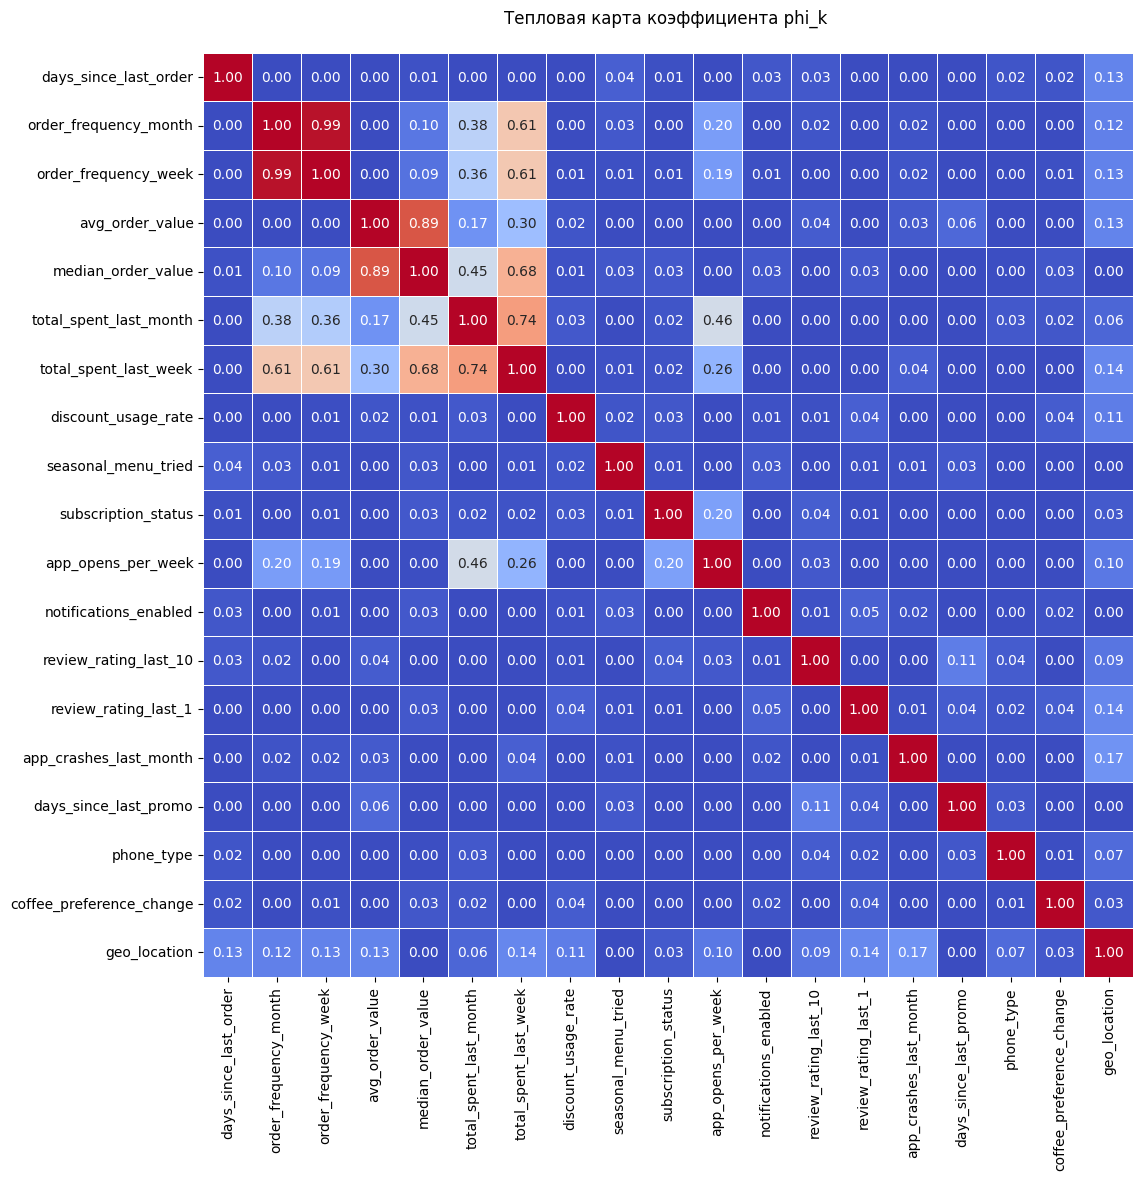

In [71]:
# Строим тепловую карту
plt.figure(figsize=(12, 12))

correlation_matrix = df_processed.drop(columns='churn').phik_matrix(interval_cols=num_features)

# Сохраняем матрицу корреляции признака churn с другими признаками клиента
data_heatmap = correlation_matrix
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n')

# Выводим график
plt.show()

In [72]:
df_processed = df_processed.drop(columns=['order_frequency_week', 'total_spent_last_week', 'avg_order_value']).reset_index(drop=True)

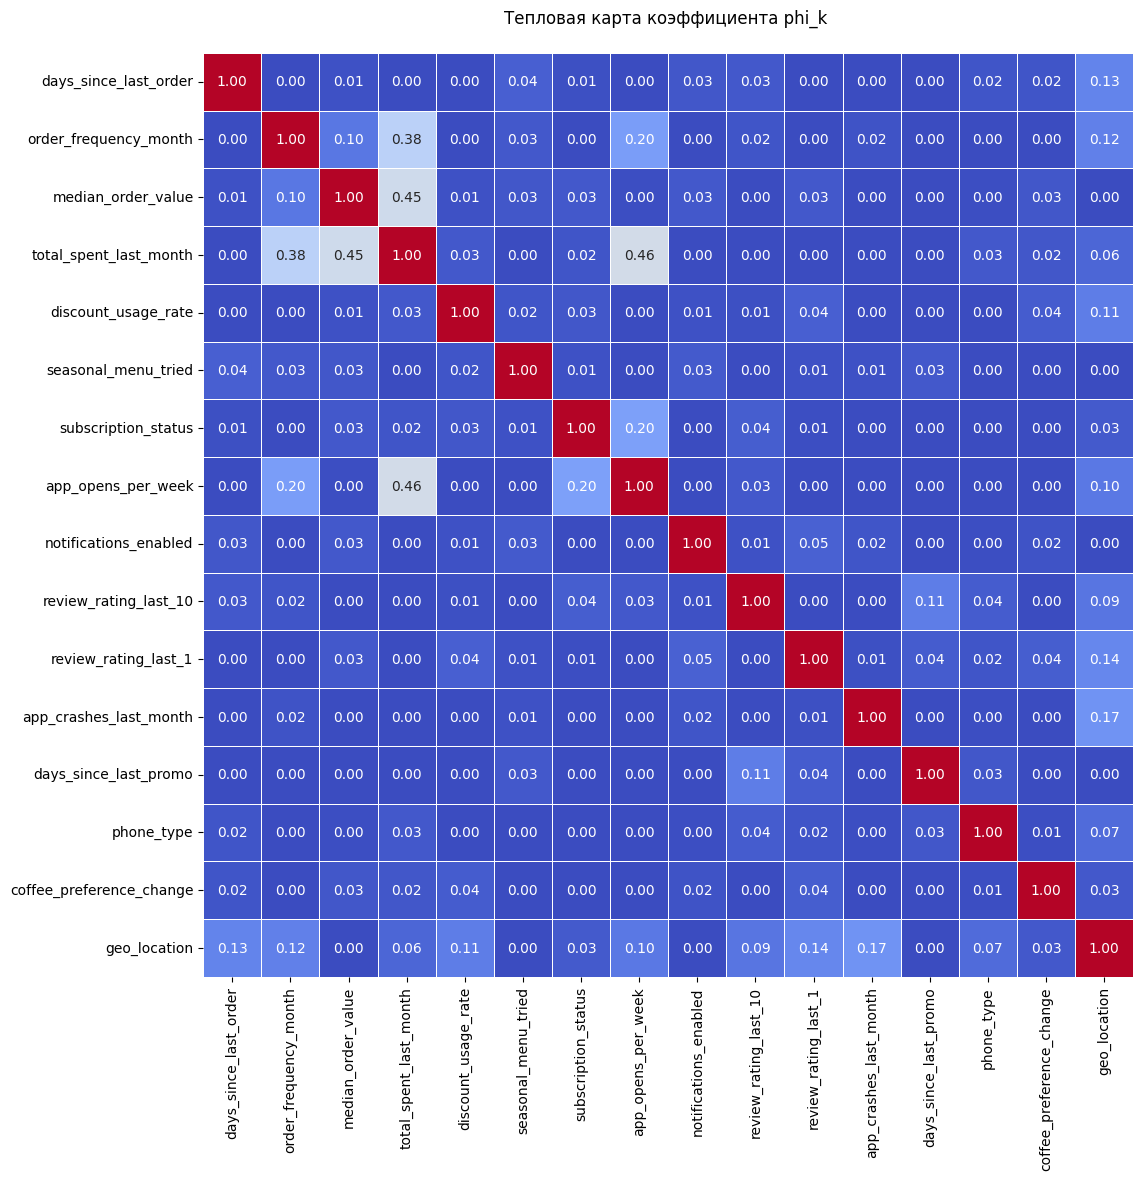

In [73]:
# Строим тепловую карту
plt.figure(figsize=(12, 12))

correlation_matrix = df_processed.drop(columns='churn').phik_matrix(interval_cols=num_features)

# Сохраняем матрицу корреляции признака churn с другими признаками клиента
data_heatmap = correlation_matrix
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n')

# Выводим график
plt.show()

In [74]:
df_processed.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     9505 non-null   float64
 1   order_frequency_month     10428 non-null  float64
 2   median_order_value        9619 non-null   float64
 3   total_spent_last_month    10420 non-null  float64
 4   discount_usage_rate       10053 non-null  float64
 5   seasonal_menu_tried       9461 non-null   float64
 6   subscription_status       10450 non-null  str    
 7   app_opens_per_week        9554 non-null   float64
 8   notifications_enabled     9913 non-null   float64
 9   review_rating_last_10     9757 non-null   float64
 10  review_rating_last_1      9593 non-null   float64
 11  app_crashes_last_month    9729 non-null   float64
 12  days_since_last_promo     9719 non-null   float64
 13  phone_type                10114 non-null  str    
 14  coffee_preference

### Комментарий

На основании посчитанных коэффициентов корреляции по Пирсону, Спирману и Кендаллу выявлена сильная связь (от 0.78 до 0.98) между признаками в паре _week-_month: `order_frequency_month` - `order_frequency_week`, `total_spent_last_month` - `total_spent_last_week`. Есть смысл оставить данные за месяц, как более полные, недельные признаки - удалить.
Связь от умеренной к сильной (от 0.53 до 0.73) наблюдается также между этими группами, что тоже можно объяснить так как частота заказов влияет на итоговую выручку.
Сильная связь видна в паре `avg_order_value`, `median_order_value`, что логично, так как оба признака отражают меры центральной тенденции распределения. Так как распределения стоимости заказа имеют тенденцию к смещению вправо, имеет смысл оставить медиану, как более устойчивую к выбросам метрику. Среднее - удаляем.
Слабо-умеренная связь (0.25 - 0.42) есть между признаками `total_spent_last_month` и `app_opens_per_week`. Количество использований приложения оказывает влияние на ежемесячные траты. Что интересно корреляция с еженедельными расходами меньше (0.17 - 0.32).

Похожую картину демонстрирует Phik матрица.

Итого: удаляем дублирующие признаки `order_frequency_week` и `total_spent_last_week`, а также `avg_order_value`. Оставшиеся 16 признаков имеют слабую или умеренную корреляцию, что говорит об отсутствии взаимозависимости между ними.
___

### 2.8 Вывод по результатам исследовательского анализа данных



В ходе первичного исследовательского анализа данных по 10 450 пользователям сервиса доставки кофе выявлены ключевые закономерности поведения аудитории и особенности набора данных. Пользователи демонстрируют умеренную лояльность: среднее количество дней с последнего заказа составляет около 4,3, средняя частота заказов — чуть более 4 в месяц, а средний чек находится на уровне ~1063 рублей при значительном разбросе значений (от отрицательных до 5901 рубля). Активное взаимодействие с приложением подтверждается средним показателем 11 открытий в неделю, при этом около 75 % пользователей регулярно пробуют новинки. Наиболее популярным сортом кофе является арабика (более 60 % пользователей), предпочтительной обжаркой — средняя, а размером порции — средний (около 50 % заказов).

Целевая переменная `churn` (отток клиентов) демонстрирует выраженный дисбаланс: лишь 6 % пользователей прекратили пользоваться сервисом за последние 4 недели, тогда как 94 % остались активными. Это потребует учёта при построении моделей прогнозирования оттока.

Исходный набор данных включал 26 признаков, из которых были исключены `user_id` как не несущий аналитической ценности и `seasons` из‑за неясности интерпретации в контексте агрегированных за 4 недели данных. Оставшиеся 24 признака содержали пропуски различной степени выраженности (от 2–3 % до 9,5 %). Для их обработки применены дифференцированные стратегии: числовые признаки заполнялись мерами центральной тенденции (средним или медианой), категориальные — наиболее частыми значениями, бинарные — с учётом их распределения, а для парных week‑month показателей использовано пропорциональное восстановление (деление/умножение на 4). Это позволило снизить долю пропусков в ключевых финансовых признаках с 2–9 % до 0,2 %.

Категориальные признаки проанализированы на предмет кодировки и генерации новых метрик. Признаки `coffee_bean_origin`, `last_coffee_type`, `preferred_roast`, `milk_preference` и `last_drink_size` исключены из дальнейшего анализа как слабо влияющие на целевую переменную. Для остальных применены методы кодирования: One‑hot для `subscription_status` и `phone_type` (3–4 уникальных значения), Target Encoding для `geo_location` (100 уникальных значений). Потенциально значимый новый признак может быть создан на основе комбинации `subscription_status` и `phone_type` для изучения связи между типом устройства и статусом подписки.

Выбросы обнаружены в ряде числовых признаков со скошенным вправо распределением (`days_since_last_order`, `avg_order_value` и др.). Их удаление признано нецелесообразным, так как они отражают реальные паттерны поведения пользователей. Вместо этого предложено использовать преобразования (логарифмирование, квадратный корень) для снижения влияния асимметрии. Отрицательные значения в `review_rating_last_1` интерпретированы как ошибки и заменены на 0.

Анализ корреляций выявил сильные связи между week‑ и month‑версиями признаков (`order_frequency`, `total_spent`) и между `avg_order_value` и `median_order_value`. В результате из набора исключены `order_frequency_week`, `total_spent_last_week` и `avg_order_value`, оставлены более устойчивые метрики (медианные и месячные показатели). Оставшиеся 16 признаков демонстрируют слабую или умеренную корреляцию, что подтверждает их независимость и пригодность для моделирования.

Итоговый набор данных после предобработки включает 16 информативных признаков, сбалансированно отражающих поведение пользователей и характеристики их заказов, с минимизированными пропусками и оптимизированной структурой для дальнейшего построения моделей прогнозирования оттока.
___


## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



### 3.1 Разделяем данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные для обучения и кросс-валидации модели.

In [75]:
# Разделяем признаки и целевую переменную
X = df_processed.drop(columns=['churn'])
y = df_processed['churn']

# Напишите код для разделения данных на train и test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=random_state)


In [76]:
X.head()

,days_since_last_order,order_frequency_month,median_order_value,total_spent_last_month,discount_usage_rate,seasonal_menu_tried,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,phone_type,coffee_preference_change,geo_location
0,0.0,12.942519,260.645081,3089.991009,0.337031,NaN,pro,30.468321,1.0,5.176792,3.302238,NaN,6.0,android,0.0,geo_75
1,2.0,1.569146,540.597839,998.380941,0.547659,1.0,none,NaN,1.0,4.392991,NaN,0.0,16.0,ios,0.0,geo_95
2,11.0,2.996666,471.494568,1328.140204,0.120258,1.0,premium,17.895638,1.0,4.977713,4.379219,0.0,11.0,web,1.0,geo_25
3,0.0,4.299255,708.529785,2999.628366,NaN,0.0,none,11.405533,1.0,3.712526,3.043617,0.0,3.0,android,0.0,geo_2
4,3.0,7.249865,1199.372925,8377.729478,0.074990,1.0,none,15.948238,0.0,4.528271,5.642993,1.0,14.0,ios,0.0,geo_19


In [77]:
y[:5]

0    1
1    0
2    0
3    0
4    1
Name: churn, dtype: int64

### 3.2 Предобработка данных. Информацию о пропусках и категориальных признаках используется только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.

In [78]:
# Обновляем состав переменных cat_features, num_features, binary_features

cat_features_ohe = ['subscription_status', 'phone_type']
cat_features_te = ['geo_location']

binary_features = ['seasonal_menu_tried', 'notifications_enabled', 'coffee_preference_change']
num_features_right_skewed = [
    'days_since_last_order',
    'order_frequency_month',
    'median_order_value',
    'total_spent_last_month',
    'discount_usage_rate',
    'app_opens_per_week',
    'app_crashes_last_month',
    'days_since_last_promo'
]
num_features_normal = ['review_rating_last_10', 'review_rating_last_1']

In [79]:
cat_imputer = SimpleImputer(strategy='most_frequent')
num_imputer_right_skewed = SimpleImputer(strategy='median')
num_imputer_normal = SimpleImputer(strategy='mean')
zero_imputer = SimpleImputer(strategy='constant', fill_value=0)

one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
target_encoder = TargetEncoder()

std_scaler = StandardScaler()

In [80]:
# Функция замены выбросов
def clip_outliers(X, lower_percentile=1, upper_percentile=99):

    X = np.array(X)
    X_clipped = np.zeros_like(X)

    for i in range(X.shape[1]):
        col = X[:, i]
        if lower_percentile == 0:
            lower_bound = 0
        else:    
            lower_bound = np.percentile(col, lower_percentile)
        
        if upper_percentile == None:
            upper_bound = None
        else:
            upper_bound = np.percentile(col, upper_percentile)
        
        X_clipped[:, i] = np.clip(col, lower_bound, upper_bound)

    return X_clipped

In [81]:
# Пайплайн, который обработает пропуски и выбросы в числовых признаках

num_clip_outliers_transformer = FunctionTransformer(
    func=clip_outliers,
    kw_args={'lower_percentile': 1, 'upper_percentile': 99},
    validate=True
    )

num_pipeline_right_skewed = Pipeline(
    steps=[
        ('fillna', num_imputer_right_skewed),
        ('clipoutliers', num_clip_outliers_transformer),
        ('standartization', std_scaler)
    ]
)

num_pipeline_normal = Pipeline(
    steps=[
        ('fillna', num_imputer_normal),
        ('clipoutliers', num_clip_outliers_transformer),
        ('standartization', std_scaler)
    ]
)


In [82]:
# Пайплайн, который обработает категориальные признаки

cat_pipeline_ohe = Pipeline(
    steps=[
        ('fillna', cat_imputer),
        ('one_hot_encoder', one_hot_encoder)
    ]
)

cat_pipeline_te = Pipeline(
    steps=[
        ('fillna', cat_imputer),
        ('target_encoder', target_encoder)
    ]
)

binary_pipeline = Pipeline(
    steps=[
        ('fillna', zero_imputer)
    ]
)

In [83]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num_right_skewed', num_pipeline_right_skewed, num_features_right_skewed),
        ('num_normal', num_pipeline_normal, num_features_normal),
        ('cat_ohe', cat_pipeline_ohe, cat_features_ohe),
        ('cat_te', cat_pipeline_te, cat_features_te),
        ('binary', binary_pipeline, binary_features)
    ]
)

In [84]:
X_train_val_transformed = preprocessor.fit_transform(X_train_val, y_train_val)

In [85]:
# После fit_transform получаем имена от OneHotEncoder напрямую
ohe_transformer = preprocessor.named_transformers_['cat_ohe']
ohe_names = ohe_transformer.named_steps['one_hot_encoder'].get_feature_names_out(cat_features_ohe)

# Собираем все имена
all_names = (
    num_features_right_skewed +
    num_features_normal +
    list(ohe_names) +
    cat_features_te +
    binary_features
)


In [86]:
pd.DataFrame(X_train_val_transformed, columns=all_names)

,days_since_last_order,order_frequency_month,median_order_value,total_spent_last_month,discount_usage_rate,app_opens_per_week,app_crashes_last_month,days_since_last_promo,review_rating_last_10,review_rating_last_1,subscription_status_none,subscription_status_premium,subscription_status_pro,phone_type_ios,phone_type_web,geo_location,seasonal_menu_tried,notifications_enabled,coffee_preference_change
0,-0.950791,-1.042638,0.130720,-0.784128,-1.099686,-0.781812,1.030725,-0.082994,-0.722146,-1.437448,0.0,0.0,0.0,0.0,0.0,0.068768,1.0,0.0,0.0
1,2.429487,2.518903,1.013403,3.194812,2.082339,0.825192,-0.010839,-0.153398,0.078185,-0.516538,0.0,1.0,0.0,0.0,0.0,0.070305,0.0,0.0,0.0
2,-0.725439,-1.018501,-1.593706,-0.978351,-0.121860,-1.016003,-0.010839,0.761854,0.745888,-0.000531,1.0,0.0,0.0,1.0,0.0,0.010107,0.0,1.0,0.0
3,0.626672,-0.083331,0.523837,0.349844,-0.567223,-0.032732,-0.010839,1.254683,-1.765604,0.743069,1.0,0.0,0.0,1.0,0.0,0.045637,1.0,1.0,0.0
4,3.781598,-0.534175,0.312781,-0.365276,-0.394172,0.188715,1.030725,-0.575823,1.262131,-0.335666,1.0,0.0,0.0,0.0,0.0,0.079059,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8355,0.401320,-0.243559,-1.091564,-0.733369,0.219569,0.121598,-1.052403,1.254683,0.842935,0.796205,1.0,0.0,0.0,0.0,0.0,0.045637,1.0,1.0,0.0
8356,-0.049383,0.189464,-0.428647,-0.162662,1.401681,0.193409,-0.010839,1.254683,0.838479,0.230322,0.0,0.0,1.0,1.0,0.0,0.064868,1.0,1.0,1.0
8357,-0.274735,-0.309204,-1.283382,-0.758546,-0.358314,-0.853668,-0.010839,-0.294206,0.000134,0.583741,0.0,0.0,0.0,0.0,0.0,0.096407,1.0,1.0,0.0
8358,-0.500087,-0.329238,0.277946,-0.155023,0.093889,0.601280,-0.010839,1.043471,0.244717,0.293736,1.0,0.0,0.0,0.0,0.0,0.001452,1.0,1.0,1.0


## Комментарий

Датасет разделен на выборки для обучения и кросс-валидации и тестовую выборку в соотношении 80 к 20. 20% - для теста.

Составлены пайплайны для числовых признаков со смещенным вправо распределением, для числовых признаков с нормальным распределением, для категориальных и для бинарных признаков. Пайплайны для числовых атрибутов включают замену пропусков путем добавления мер центральной тенденции медианы для смещенных вправо и среднего для нормального, удаления выбросов по границе 1-го и 99-го перцентиля. В дальнейшем выбросы будут обрабатываться в рамках преобразования признаков через логарифм и квадратный корень, так как они потенциально несут в себе ценную информацию. В заключении числовые признаки масштабируются через стандартизацию.  
Категориальные признаки кодируются методом Target Encoding и One hot encoding.

Пустые значения в бинарных признаков заполяются нулями исходя из той логики, что если нам неизвестно значения признака, то скорее это его отсутствие (0), чем наличие (1). Например, если мы ничего не знаем о включённых оповещениях на телефоне пользователя, то скорее они отсутствуют. 

___

## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

### 4.1 Обучение базовой модели

In [87]:
# Создание модели DummyClassifier

dummy_classifier = DummyClassifier(strategy='stratified', random_state=random_state)

In [88]:
# Создание полного пайплана с моделью классификции

logreg_model = LogisticRegression(random_state=random_state)

full_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', logreg_model)
    ]
)

In [89]:
# Выбираем метрики модели Precision, Recall, F1, PR-AUC
scoring = ['precision', 'recall', 'f1', 'average_precision']

# Собираем кросс-валидацию
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

cv_dummy = cross_validate(
    estimator=dummy_classifier,
    X=X_train_val,
    y=y_train_val,
    scoring=scoring,
    cv=kfold
)

cv_results = cross_validate(
    estimator=full_pipeline,
    X=X_train_val,
    y=y_train_val,
    scoring=scoring,
    cv=kfold,
    return_estimator=True
    )

### 4.2 Метрики и коэффициенты базовой модели

In [90]:
all_coefficients = []
for i, estimator in enumerate(cv_results['estimator']):
    logreg = estimator.named_steps['classifier']
    coefs = logreg.coef_[0]
    all_coefficients.append(coefs)

# Анализ — аналогично способу 2
coef_array = np.array(all_coefficients)
mean_coef = np.mean(coef_array, axis=0)

In [91]:
pd.DataFrame([mean_coef.round(4)], columns=all_names).T.sort_values(by=0, ascending=False)

,0
geo_location,2.4222
app_crashes_last_month,2.1994
subscription_status_pro,0.9936
order_frequency_month,0.6503
app_opens_per_week,0.4078
subscription_status_premium,0.3426
median_order_value,0.1778
days_since_last_promo,0.0996
review_rating_last_1,0.0881
coffee_preference_change,0.0319


In [92]:
cv_dummy_means = {
    'precision': cv_dummy['test_precision'].mean().round(3),
    'recall': cv_dummy['test_recall'].mean().round(3),
    'f1': cv_dummy['test_f1'].mean().round(3),
    'pr_auc': cv_dummy['test_average_precision'].mean().round(3)
} 

In [93]:
cv_dummy_means

{'precision': np.float64(0.075),
 'recall': np.float64(0.079),
 'f1': np.float64(0.077),
 'pr_auc': np.float64(0.062)}

In [94]:
cv_metric_means = {
    'precision': cv_results['test_precision'].mean().round(3),
    'recall': cv_results['test_recall'].mean().round(3),
    'f1': cv_results['test_f1'].mean().round(3),
    'pr_auc': cv_results['test_average_precision'].mean().round(3)
} 

In [95]:
cv_metric_means

{'precision': np.float64(0.769),
 'recall': np.float64(0.475),
 'f1': np.float64(0.583),
 'pr_auc': np.float64(0.681)}

In [96]:
print('Результаты dummy и базовой модели (средние значения):')
print('-' * 50)
print(f'F1:     {cv_metric_means['f1']:.3f}')
print(f'PR-AUC: {cv_metric_means['pr_auc']:.3f}')

# Сравнение с базовой моделью
print('\nСравнение моделей:')
print('-' * 50)
print(f'{'Метрика':<12} {'Dummy':<12} {'Базовая':<12} {'Изменение':<10}')
print('-' * 50)

dummy_means = {
    'f1': cv_dummy_means['f1'],
    'pr_auc': cv_dummy_means['pr_auc']
}

for metric in ['f1', 'pr_auc']:
    dummy_mean = cv_dummy_means[metric]
    base_mean = cv_metric_means[metric]

    change = base_mean - dummy_mean
    change_str = f'{change:+.3f}'

    print(
        f'{metric.upper():<12} {dummy_mean:<12.3f} {base_mean:<12.3f} {change_str:<10}'
    )

Результаты dummy и базовой модели (средние значения):
--------------------------------------------------
F1:     0.583
PR-AUC: 0.681

Сравнение моделей:
--------------------------------------------------
Метрика      Dummy        Базовая      Изменение 
--------------------------------------------------
F1           0.077        0.583        +0.506    
PR_AUC       0.062        0.681        +0.619    


### Комментарий

Обучены dummy и модель LogisticRegression на тренировочной выборки. Результаты работы dummy (baseline) модели : `precision` 0.075, `recall` 0.079, `f1` 0.077, `pr_auc` 0.062, что в целом соответствует случайной генерации меток по вероятностями из y_train.

Модель LogisticRegression выстроена на базе построенного пайплайна с заполнением пропусков, удалением выбросов, стандартизацией признаков и обработкой категориальных атрибутов.
Результаты: `precision`: 0.769, `recall` 0.475, `f1` 0.583, `pr_auc`: `0.681`.
Ключевые метрики **F1 больше на 0.506, PR-AUC превышает более, чем в 10 раз**.

Наиболее значимыми по модулю коэффициентов являются признаки `geo_location` - 2.4, `app_crashes_last_month` - 2.2, `subscription_status_pro` - 0.99. Это наводит на мысли о недовольных покупателях из каких-то крупных регионов, у которых не работает приложение. Но это пока тольк гипотеза. Продолжаем работать с моделью.
___

## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

### 5.1 Добавление новых признаков на основе log и sqrt.

In [97]:
log_features = ['days_since_last_order', 'median_order_value', 'total_spent_last_month', 'app_opens_per_week']
sqrt_features = ['order_frequency_month', 'days_since_last_promo', 'discount_usage_rate']

In [98]:
def create_enhanced_features(X):
    """
    Создаёт расширенный набор признаков
    """

    # Создаём копию датасета, чтобы не изменять исходный датасет
    X_enhanced = X.copy()

    # Логарифм 
    for feature in log_features:
        X_enhanced[f"{feature}_log"] = np.log1p(X_enhanced[feature]) # Ваш код здесь

    # Квадратный корень
    for feature in sqrt_features:
        X_enhanced[f"{feature}_sqrt"] = np.sqrt(X_enhanced[feature]) # Ваш код здесь

    columns_to_drop = log_features + sqrt_features
    # Удаляем указанные колонки
    X_enhanced = X_enhanced.drop(columns=columns_to_drop)

    return X_enhanced

# Создайте расширенный набор признаков
X_train_val_enhanced = create_enhanced_features(X_train_val)

print("Исходные признаки:", X_train_val.columns.tolist())
print("Новые признаки:", X_train_val_enhanced.columns.tolist())
print(f"Количество признаков: {X_train_val.shape[1]} → {X_train_val_enhanced.shape[1]}")

Исходные признаки: ['days_since_last_order', 'order_frequency_month', 'median_order_value', 'total_spent_last_month', 'discount_usage_rate', 'seasonal_menu_tried', 'subscription_status', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'phone_type', 'coffee_preference_change', 'geo_location']
Новые признаки: ['seasonal_menu_tried', 'subscription_status', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'phone_type', 'coffee_preference_change', 'geo_location', 'days_since_last_order_log', 'median_order_value_log', 'total_spent_last_month_log', 'app_opens_per_week_log', 'order_frequency_month_sqrt', 'days_since_last_promo_sqrt', 'discount_usage_rate_sqrt']
Количество признаков: 16 → 16


### 5.2 Обновление пайплайна и повторная кросс-валидация. Сравнение результатов моделей с новыми признаками и без них.

In [99]:
# Обновляем состав переменных cat_features, num_features, binary_features

cat_features_ohe = ['subscription_status', 'phone_type']
cat_features_te = ['geo_location']

binary_features = ['seasonal_menu_tried', 'notifications_enabled', 'coffee_preference_change']
num_features_right_skewed = [
    'days_since_last_order_log',
    'order_frequency_month_sqrt',
    'median_order_value_log',
    'total_spent_last_month_log',
    'discount_usage_rate_sqrt',
    'app_opens_per_week_log',
    'app_crashes_last_month',
    'days_since_last_promo_sqrt'
]
num_features_normal = ['review_rating_last_10', 'review_rating_last_1']

In [100]:
# Доработанный пайплайн, который обработает пропуски и выбросы в числовых признаках

num_pipeline_right_skewed = Pipeline(
    steps=[
        ('fillna', num_imputer_right_skewed),
        ('standartization', std_scaler)
    ]
)

num_pipeline_normal = Pipeline(
    steps=[
        ('fillna', num_imputer_normal),
        ('standartization', std_scaler)
    ]
)

In [101]:
# Пайплайн, который обработает категориальные признаки

cat_pipeline_ohe = Pipeline(
    steps=[
        ('fillna', cat_imputer),
        ('one_hot_encoder', one_hot_encoder)
    ]
)

cat_pipeline_te = Pipeline(
    steps=[
        ('fillna', cat_imputer),
        ('target_encoder', target_encoder)
    ]
)

binary_pipeline = Pipeline(
    steps=[
        ('fillna', zero_imputer)
    ]
)

In [102]:
# Обновляем preprocessor
preprocessor_enhanced = ColumnTransformer(
    transformers=[
        ('num_right_skewed', num_pipeline_right_skewed, num_features_right_skewed),
        ('num_normal', num_pipeline_normal, num_features_normal),
        ('cat_ohe', cat_pipeline_ohe, cat_features_ohe),
        ('cat_te', cat_pipeline_te, cat_features_te),
        ('binary', binary_pipeline, binary_features)
    ]
)

In [103]:
X_train_val_enhanced_transformed = preprocessor_enhanced.fit_transform(X_train_val_enhanced, y_train_val)

In [104]:
# Создание полного пайплана с моделью классификции

logreg_model = LogisticRegression(random_state=random_state)

full_pipeline_enhanced = Pipeline(
    steps=[
        ('preprocessor', preprocessor_enhanced),
        ('classifier', logreg_model)
    ]
)

In [105]:
# После fit_transform получаем имена от OneHotEncoder напрямую
ohe_transformer = preprocessor_enhanced.named_transformers_['cat_ohe']
ohe_names = ohe_transformer.named_steps['one_hot_encoder'].get_feature_names_out(cat_features_ohe)

# Собираем все имена
all_names = (
    num_features_right_skewed +
    num_features_normal +
    list(ohe_names) +
    cat_features_te +
    binary_features
)

In [106]:
cv_results_enh = cross_validate(
    estimator=full_pipeline_enhanced,
    X=X_train_val_enhanced,
    y=y_train_val,
    scoring=scoring,
    cv=kfold,
    return_estimator=True
)

In [107]:
all_coefficients = []
for i, estimator in enumerate(cv_results_enh['estimator']):
    logreg = estimator.named_steps['classifier']
    coefs = logreg.coef_[0]
    all_coefficients.append(coefs)

# Анализ — аналогично способу 2
coef_array = np.array(all_coefficients)
mean_coef = np.mean(coef_array, axis=0)

In [108]:
pd.DataFrame([mean_coef.round(4)], columns=all_names).T.sort_values(by=0, ascending=False)

,0
geo_location,2.3529
app_crashes_last_month,2.2605
subscription_status_pro,0.8575
app_opens_per_week_log,0.7942
order_frequency_month_sqrt,0.7641
median_order_value_log,0.3666
subscription_status_premium,0.2273
days_since_last_promo_sqrt,0.1267
review_rating_last_1,0.0918
subscription_status_none,0.0850


In [109]:
cv_metric_means_enh = {
    'precision': cv_results_enh['test_precision'].mean().round(3),
    'recall': cv_results_enh['test_recall'].mean().round(3),
    'f1': cv_results_enh['test_f1'].mean().round(3),
    'pr_auc': cv_results_enh['test_average_precision'].mean().round(3)
} 

In [110]:
cv_metric_means_enh

{'precision': np.float64(0.809),
 'recall': np.float64(0.495),
 'f1': np.float64(0.609),
 'pr_auc': np.float64(0.71)}

In [111]:
print('Результаты расширенной модели (средние значения):')
print('-' * 50)
print(f'F1:     {cv_metric_means_enh['f1']:.3f}')
print(f'PR-AUC: {cv_metric_means_enh['pr_auc']:.3f}')

# Сравнение с базовой моделью
print('\nСравнение моделей:')
print('-' * 50)
print(f'{'Метрика':<12} {'Базовая':<12} {'Расширенная':<12} {'Изменение':<10}')
print('-' * 50)

dummy_means = {
    'f1': cv_metric_means['f1'],
    'pr_auc': cv_metric_means['pr_auc']
}

for metric in ['f1', 'pr_auc']:
    dummy_mean = cv_metric_means[metric]
    base_mean = cv_metric_means_enh[metric]

    change = base_mean - dummy_mean
    change_str = f'{change:+.3f}'

    print(
        f'{metric.upper():<12} {dummy_mean:<12.3f} {base_mean:<12.3f} {change_str:<10}'
    )

Результаты расширенной модели (средние значения):
--------------------------------------------------
F1:     0.609
PR-AUC: 0.710

Сравнение моделей:
--------------------------------------------------
Метрика      Базовая      Расширенная  Изменение 
--------------------------------------------------
F1           0.583        0.609        +0.026    
PR_AUC       0.681        0.710        +0.029    


In [112]:
# dd = pd.DataFrame([mean_coef.round(4)], columns=all_names).T.sort_values(by=0, ascending=False)
# columns_to_drop = dd[dd[0] < np.abs(0.2)].T.columns.to_list()
columns_to_drop = [
    'days_since_last_promo_sqrt',
    'review_rating_last_1',
    'coffee_preference_change',
    'days_since_last_order_log',
    'notifications_enabled',
    'discount_usage_rate_sqrt',
    'review_rating_last_10',
    'phone_type',
    'seasonal_menu_tried',
    'total_spent_last_month_log'
]

In [113]:
X_train_val_enhanced_cut = X_train_val_enhanced.drop(columns=columns_to_drop)

In [114]:
X_train_val_enhanced_cut.info()

<class 'pandas.DataFrame'>
Index: 8360 entries, 2670 to 85
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   subscription_status         8360 non-null   str    
 1   app_crashes_last_month      7796 non-null   float64
 2   geo_location                8270 non-null   str    
 3   median_order_value_log      7686 non-null   float64
 4   app_opens_per_week_log      7624 non-null   float64
 5   order_frequency_month_sqrt  8342 non-null   float64
dtypes: float64(4), str(2)
memory usage: 457.2 KB


In [115]:
# Обновляем состав переменных cat_features, num_features, binary_features

cat_features_ohe = ['subscription_status']
cat_features_te = ['geo_location']
num_features_right_skewed = [
    'order_frequency_month_sqrt',
    'median_order_value_log',
    'app_opens_per_week_log',
    'app_crashes_last_month',
]

In [116]:
# Обновляем preprocessor
preprocessor_cut = ColumnTransformer(
    transformers=[
        ('num_right_skewed', num_pipeline_right_skewed, num_features_right_skewed),
        ('cat_ohe', cat_pipeline_ohe, cat_features_ohe),
        ('cat_te', cat_pipeline_te, cat_features_te)
    ]
)

In [117]:
X_train_val_transformed_cut = preprocessor_cut.fit_transform(X_train_val_enhanced_cut, y_train_val)

In [118]:
# Создание полного пайплана с моделью классификции

logreg_model = LogisticRegression(random_state=random_state)

full_pipeline_cut = Pipeline(
    steps=[
        ('preprocessor', preprocessor_cut),
        ('classifier', logreg_model)
    ]
)

In [119]:
# После fit_transform получаем имена от OneHotEncoder напрямую
ohe_transformer = preprocessor_cut.named_transformers_['cat_ohe']
ohe_names = ohe_transformer.named_steps['one_hot_encoder'].get_feature_names_out(cat_features_ohe)

# Собираем все имена
all_names = (
    num_features_right_skewed +
    list(ohe_names) +
    cat_features_te
)

In [120]:
cv_results_cut = cross_validate(
    estimator=full_pipeline_cut,
    X=X_train_val_enhanced_cut,
    y=y_train_val,
    scoring=scoring,
    cv=kfold,
    return_estimator=True
)

In [121]:
all_coefficients = []
for i, estimator in enumerate(cv_results_cut['estimator']):
    logreg = estimator.named_steps['classifier']
    coefs = logreg.coef_[0]
    all_coefficients.append(coefs)

# Анализ — аналогично способу 2
coef_array = np.array(all_coefficients)
mean_coef = np.mean(coef_array, axis=0)

In [122]:
pd.DataFrame([mean_coef.round(4)], columns=all_names).T.sort_values(by=0, ascending=False)

,0
geo_location,2.4125
app_crashes_last_month,2.2195
subscription_status_pro,0.9036
app_opens_per_week_log,0.6241
order_frequency_month_sqrt,0.3674
subscription_status_premium,0.2573
subscription_status_none,0.0664
median_order_value_log,-0.0308


In [127]:
cv_metric_means_cut = {
    'precision': cv_results_cut['test_precision'].mean().round(3),
    'recall': cv_results_cut['test_recall'].mean().round(3),
    'f1': cv_results_cut['test_f1'].mean().round(3),
    'pr_auc': cv_results_cut['test_average_precision'].mean().round(3)
} 

In [128]:
cv_metric_means_cut

{'precision': np.float64(0.808),
 'recall': np.float64(0.495),
 'f1': np.float64(0.612),
 'pr_auc': np.float64(0.707)}

In [129]:
print('Результаты расширенной модели (средние значения):')
print('-' * 50)
print(f'F1:     {cv_metric_means_cut['f1']:.3f}')
print(f'PR-AUC: {cv_metric_means_cut['pr_auc']:.3f}')

# Сравнение с базовой моделью
print('\nСравнение моделей:')
print('-' * 50)
print(f'{'Метрика':<12} {'Расширенная':<12} {'Сокращённая':<12} {'Изменение':<10}')
print('-' * 50)

dummy_means = {
    'f1': cv_metric_means['f1'],
    'pr_auc': cv_metric_means['pr_auc']
}

for metric in ['f1', 'pr_auc']:
    dummy_mean = cv_metric_means_enh[metric]
    base_mean = cv_metric_means_cut[metric]

    change = base_mean - dummy_mean
    change_str = f'{change:+.3f}'

    print(
        f'{metric.upper():<12} {dummy_mean:<12.3f} {base_mean:<12.3f} {change_str:<10}'
    )

Результаты расширенной модели (средние значения):
--------------------------------------------------
F1:     0.612
PR-AUC: 0.707

Сравнение моделей:
--------------------------------------------------
Метрика      Расширенная  Сокращённая  Изменение 
--------------------------------------------------
F1           0.609        0.612        +0.003    
PR_AUC       0.710        0.707        -0.003    


### Комментарий

После модификации признаков при помощи функций квадратного корня и логарифма качество модели удалось улучшить.

Результаты работы новой расширенной модели : `precision` 0.809, `recall` 0.495, `f1` 0.609, `pr_auc` 0.71. Это в среднем на 0.02 выше , чем модель без модификации параметров.
Ключевые метрики **F1 больше на 0.026, PR-AUC вырос на 0.029**.

Наиболее значимыми по модулю коэффициентов по-прежнему являются признаки `geo_location` - 2.35, `app_crashes_last_month` - 2.26, `subscription_status_pro` - 0.85.  

Удаление признаков с малыми значениями коэффициентов практически не повлияло на качество модели.
___

## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.